# Final Model: Full Fine-tuning 4-crop DenseNet121, Loss Penalty Ablation, Multi-seed Robustness, and Confidence Analysis

This notebook treats **Full Fine-tuning** as the final training strategy.

It includes four main parts:

1. **Loss penalty ablation**: tests different `alpha`, `penalty_distance`, `square_loss`, and `normalize` settings for the Hybrid Chen Ordinal Loss.
2. **Final model training**: trains the final Full Fine-tuning model using the best loss penalty setting selected by validation QWK.
3. **Multi-seed robustness experiment**: repeats the final model under multiple random seeds.
4. **Confidence / calibration analysis**: estimates model confidence using softmax probability, margin, entropy, and ECE.


## 1. Imports & Environment Setup

In [1]:
from pathlib import Path
import os
import random
import json
import time
import math
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score,
   ConfusionMatrixDisplay
)

from tqdm import tqdm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration Section

This section records all key experimental settings to make the experiment reproducible.

In [2]:
CONFIG = {
    "EXPERIMENT_NAME": "final_full_finetuning_4crop_multiseed_confidence",
    "IMG_SIZE": 320,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "LR": 5e-5,
    "WEIGHT_DECAY": 0.0,

    # Main seed used for the first final model run.
    "SEED": 42,


    # Loss penalty ablation.
    # This should be run before the final model training, because it selects
    # the best alpha / penalty_distance / square_loss / normalize setting using validation QWK.
    "RUN_LOSS_PENALTY_ABLATION": True,
    "LOSS_ABLATION_MODE": "two_stage",  # "two_stage" is faster; "full_grid" is more complete but much slower.
    "LOSS_ABLATION_SEED": 42,
    "LOSS_ABLATION_EPOCHS": 12,
    "LOSS_ABLATION_PATIENCE": 4,
    "LOSS_ABLATION_ALPHA_VALUES": [0.0, 0.05, 0.10, 0.20, 0.30],
    "LOSS_ABLATION_PENALTY_DISTANCE_VALUES": [1, 2, 3],
    "LOSS_ABLATION_SQUARE_LOSS_VALUES": [False, True],
    "LOSS_ABLATION_NORMALIZE_VALUES": [True, False],

    # Multi-seed robustness experiment.
    # The same final full fine-tuning model will be repeated under these seeds.
    "SEEDS": [42, 123, 2024, 3407, 777],
    "RUN_MULTI_SEED": True,

    # More reproducible setting. It can be slightly slower.
    "DETERMINISTIC": True,

    # Confidence / calibration analysis.
    "RUN_CONFIDENCE_ANALYSIS": True,
    "CONFIDENCE_BINS": 10,

    "MODEL_NAME": "4-crop DenseNet121 Full Fine-tuning",
    "LOSS": "ClassWeightedHybridChenOrdinalLoss",
    "LOSS_SELECTION_METRIC": "val_qwk",
    "NUM_CLASSES": 5,
    "NUM_CROPS": 4,
    "CROP_NAMES": ["wide", "center", "left_edge", "right_edge"],
    "DROPOUT": 0.3,
    "ORDINAL_ALPHA": 0.20,
    "PENALTY_DISTANCE": 2,
    "SQUARE_LOSS": False,
    "NORMALIZE_MATRIX": True,
    "USE_AMP": True,
    "NUM_WORKERS": 0,
    "PATIENCE": 7,

    # Full fine-tuning does not use a frozen warm-up stage.
    "FREEZE_EPOCHS": 0,
    "SELECTION_METRIC": "val_qwk",

    # Kaggle path. Change this if your uploaded dataset name/path is different.
    "DATA_ROOT": "/kaggle/input/datasets/joylyuyue/split-data",
}

# 4-crop relative crop boxes
CROP_CONFIG = {
    "CENTER_CROP_WIDTH_RATIO": 0.70,
    "CENTER_CROP_HEIGHT_RATIO": 0.80,
    "EDGE_CROP_WIDTH_RATIO": 0.55,
    "EDGE_CROP_HEIGHT_RATIO": 0.80,
    "LEFT_CENTER_X_RATIO": 0.30,
    "RIGHT_CENTER_X_RATIO": 0.70,
    "CENTER_X_RATIO": 0.50,
    "CENTER_Y_RATIO": 0.50,
}

# Final model training strategy.
# We directly use Full Fine-tuning as the final model.
FINETUNING_EXPERIMENTS = [
    {
        "name": "full_finetuning",
        "freeze_backbone_first": False,
        "freeze_epochs": 0,
        "description": "Final model: train DenseNet121 backbone and classifier from epoch 1.",
    },
]

print(json.dumps(CONFIG, indent=2))
print(json.dumps(CROP_CONFIG, indent=2))
print(pd.DataFrame(FINETUNING_EXPERIMENTS))


{
  "EXPERIMENT_NAME": "final_full_finetuning_4crop_multiseed_confidence",
  "IMG_SIZE": 320,
  "BATCH_SIZE": 16,
  "EPOCHS": 30,
  "LR": 5e-05,
  "WEIGHT_DECAY": 0.0,
  "SEED": 42,
  "RUN_LOSS_PENALTY_ABLATION": true,
  "LOSS_ABLATION_MODE": "two_stage",
  "LOSS_ABLATION_SEED": 42,
  "LOSS_ABLATION_EPOCHS": 12,
  "LOSS_ABLATION_PATIENCE": 4,
  "LOSS_ABLATION_ALPHA_VALUES": [
    0.0,
    0.05,
    0.1,
    0.2,
    0.3
  ],
  "LOSS_ABLATION_PENALTY_DISTANCE_VALUES": [
    1,
    2,
    3
  ],
  "LOSS_ABLATION_SQUARE_LOSS_VALUES": [
    false,
    true
  ],
  "LOSS_ABLATION_NORMALIZE_VALUES": [
    true,
    false
  ],
  "SEEDS": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "RUN_MULTI_SEED": true,
  "DETERMINISTIC": true,
  "RUN_CONFIDENCE_ANALYSIS": true,
  "CONFIDENCE_BINS": 10,
  "MODEL_NAME": "4-crop DenseNet121 Full Fine-tuning",
  "LOSS": "ClassWeightedHybridChenOrdinalLoss",
  "LOSS_SELECTION_METRIC": "val_qwk",
  "NUM_CLASSES": 5,
  "NUM_CROPS": 4,
  "CROP_NAMES": [
  

## 3. Dataset Paths

The dataset should have the following Kaggle structure:

```text
/kaggle/input/datasets/joylyuyue/split-data/train
/kaggle/input/datasets/joylyuyue/split-data/val
/kaggle/input/datasets/joylyuyue/split-data/test
```

In [3]:
DATA_ROOT = Path(CONFIG["DATA_ROOT"])

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

OUTPUT_DIR = Path("/kaggle/working") / CONFIG["EXPERIMENT_NAME"]
RESULTS_DIR = OUTPUT_DIR / "results"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"

for p in [OUTPUT_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
OUTPUT_DIR: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence
Dataset paths are valid.


## 4. Seed Fixing

In [4]:
def set_seed(seed=42, deterministic=True):
    """Fix random seeds for Python, NumPy, PyTorch, CUDA, and DataLoader reproducibility."""
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        # More reproducible, but slightly slower.
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

        # warn_only=True avoids stopping training if one GPU operation is not fully deterministic.
        torch.use_deterministic_algorithms(True, warn_only=True)
    else:
        # Faster, but not fully deterministic.
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


set_seed(CONFIG["SEED"], deterministic=CONFIG["DETERMINISTIC"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Data Preprocessing

This experiment uses the selected tuned preprocessing:

- image size: 320
- light augmentation for training only
- no random augmentation for validation/test
- four anatomical crops:
  - `wide`: whole knee structure
  - `center`: central joint space
  - `left_edge`: left joint edge
  - `right_edge`: right joint edge

In [5]:
MEAN = [0.485, 0.485, 0.485]
STD = [0.229, 0.229, 0.229]

def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = int(width * width_ratio)
    crop_h = int(height * height_ratio)

    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)

    left = max(0, cx - crop_w // 2)
    upper = max(0, cy - crop_h // 2)
    right = min(width, left + crop_w)
    lower = min(height, upper + crop_h)

    # Adjust if clipping changed box size
    left = max(0, right - crop_w)
    upper = max(0, lower - crop_h)

    return (left, upper, right, lower)


class MultiCropTransform:
    def __init__(self, img_size=320, train=False):
        self.img_size = img_size
        self.train = train

        if train:
            self.pre_crop_aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomAffine(
                    degrees=5,
                    translate=(0.02, 0.02),
                    scale=(0.97, 1.03),
                    fill=0
                ),
            ])
        else:
            self.pre_crop_aug = None

        self.post_crop_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])

    def __call__(self, img):
        img = img.convert("RGB")

        if self.pre_crop_aug is not None:
            img = self.pre_crop_aug(img)

        w, h = img.size

        crops = []

        # 1. wide crop: full image
        crops.append(img)

        # 2. center crop: central joint space
        center_box = make_crop_box(
            w, h,
            CROP_CONFIG["CENTER_X_RATIO"],
            CROP_CONFIG["CENTER_Y_RATIO"],
            CROP_CONFIG["CENTER_CROP_WIDTH_RATIO"],
            CROP_CONFIG["CENTER_CROP_HEIGHT_RATIO"]
        )
        crops.append(img.crop(center_box))

        # 3. left edge crop
        left_box = make_crop_box(
            w, h,
            CROP_CONFIG["LEFT_CENTER_X_RATIO"],
            CROP_CONFIG["CENTER_Y_RATIO"],
            CROP_CONFIG["EDGE_CROP_WIDTH_RATIO"],
            CROP_CONFIG["EDGE_CROP_HEIGHT_RATIO"]
        )
        crops.append(img.crop(left_box))

        # 4. right edge crop
        right_box = make_crop_box(
            w, h,
            CROP_CONFIG["RIGHT_CENTER_X_RATIO"],
            CROP_CONFIG["CENTER_Y_RATIO"],
            CROP_CONFIG["EDGE_CROP_WIDTH_RATIO"],
            CROP_CONFIG["EDGE_CROP_HEIGHT_RATIO"]
        )
        crops.append(img.crop(right_box))

        crop_tensors = [self.post_crop_transform(crop) for crop in crops]
        return torch.stack(crop_tensors, dim=0)


train_transform = MultiCropTransform(img_size=CONFIG["IMG_SIZE"], train=True)
valid_transform = MultiCropTransform(img_size=CONFIG["IMG_SIZE"], train=False)

print("Train transform: 4-crop + light augmentation")
print("Validation/Test transform: 4-crop deterministic preprocessing")

Train transform: 4-crop + light augmentation
Validation/Test transform: 4-crop deterministic preprocessing


## 6. Dataset & Dataloader

This section prints the train/validation/test sizes and class distribution.

In [6]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=valid_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=valid_transform)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print("Number of classes:", len(class_names))
print("Class mapping:", class_to_idx)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)
    return np.array([label for _, label in dataset.samples])

def count_classes(dataset, split_name):
    targets = get_targets(dataset)
    rows = []
    for idx, name in enumerate(dataset.classes):
        rows.append({
            "split": split_name,
            "class_idx": idx,
            "class_name": name,
            "count": int((targets == idx).sum())
        })
    return pd.DataFrame(rows)

dist_df = pd.concat([
    count_classes(train_dataset, "train"),
    count_classes(val_dataset, "val"),
    count_classes(test_dataset, "test"),
], ignore_index=True)

display(dist_df)

train_targets = get_targets(train_dataset)
class_counts = np.bincount(train_targets, minlength=CONFIG["NUM_CLASSES"])

class_weights_np = class_counts.sum() / (CONFIG["NUM_CLASSES"] * class_counts)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

class_weight_df = pd.DataFrame({
    "class_idx": list(range(CONFIG["NUM_CLASSES"])),
    "class_name": class_names,
    "train_count": class_counts,
    "class_weight": class_weights_np
})
display(class_weight_df)

print("Class weights:", class_weights.detach().cpu().numpy())

Number of classes: 5
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Train size: 1024
Val size: 146
Test size: 294


,split,class_idx,class_name,count
0,train,0,0Normal,316
1,train,1,1Doubtful,308
2,train,2,2Mild,134
3,train,3,3Moderate,122
4,train,4,4Severe,144
5,val,0,0Normal,45
6,val,1,1Doubtful,44
7,val,2,2Mild,19
8,val,3,3Moderate,18
9,val,4,4Severe,20


,class_idx,class_name,train_count,class_weight
0,0,0Normal,316,0.648101
1,1,1Doubtful,308,0.664935
2,2,2Mild,134,1.528358
3,3,3Moderate,122,1.678689
4,4,4Severe,144,1.422222


Class weights: [0.6481013  0.66493505 1.5283582  1.6786885  1.4222223 ]


In [7]:
def seed_worker(worker_id):
    """Make DataLoader workers reproducible."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_loaders(batch_size, seed=42):
    """Create train/val/test loaders with seed-controlled training shuffle."""
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=g,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
    )

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = create_loaders(
    CONFIG["BATCH_SIZE"],
    seed=CONFIG["SEED"]
)

batch_crops, batch_labels = next(iter(train_loader))
print("Batch crops shape:", batch_crops.shape)
print("Batch labels shape:", batch_labels.shape)
print("Expected shape: [B, 4, 3, IMG_SIZE, IMG_SIZE]")

Batch crops shape: torch.Size([16, 4, 3, 320, 320])
Batch labels shape: torch.Size([16])
Expected shape: [B, 4, 3, IMG_SIZE, IMG_SIZE]


## 7. Visualization

This section displays:

1. original image
2. transformed 4-crop sample
3. CLAHE preview
4. augmented 4-crop examples

CLAHE is shown only as a visual reference and is **not** used in training for this experiment.

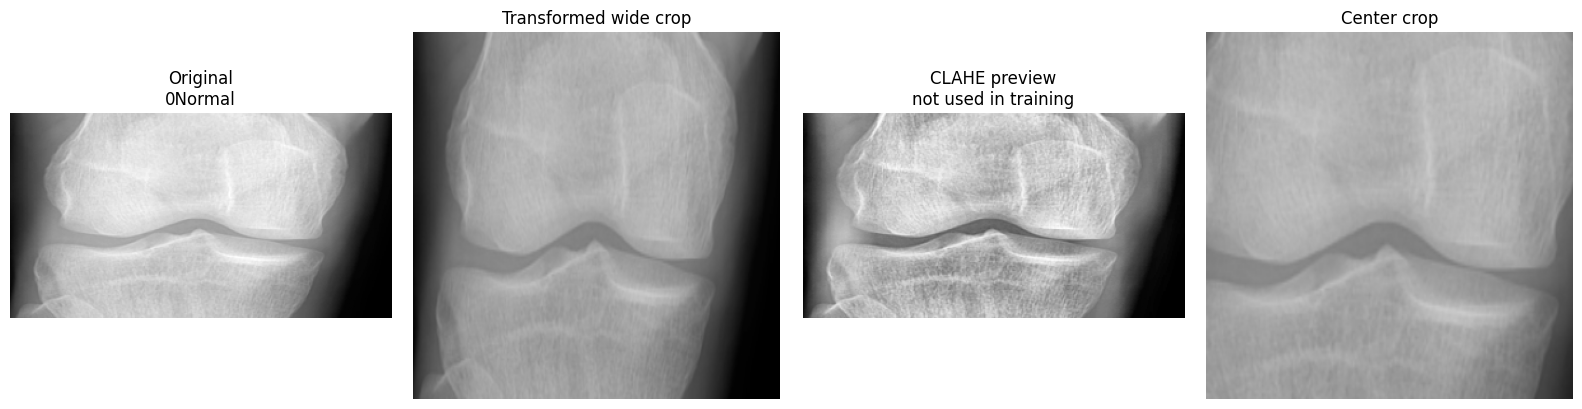

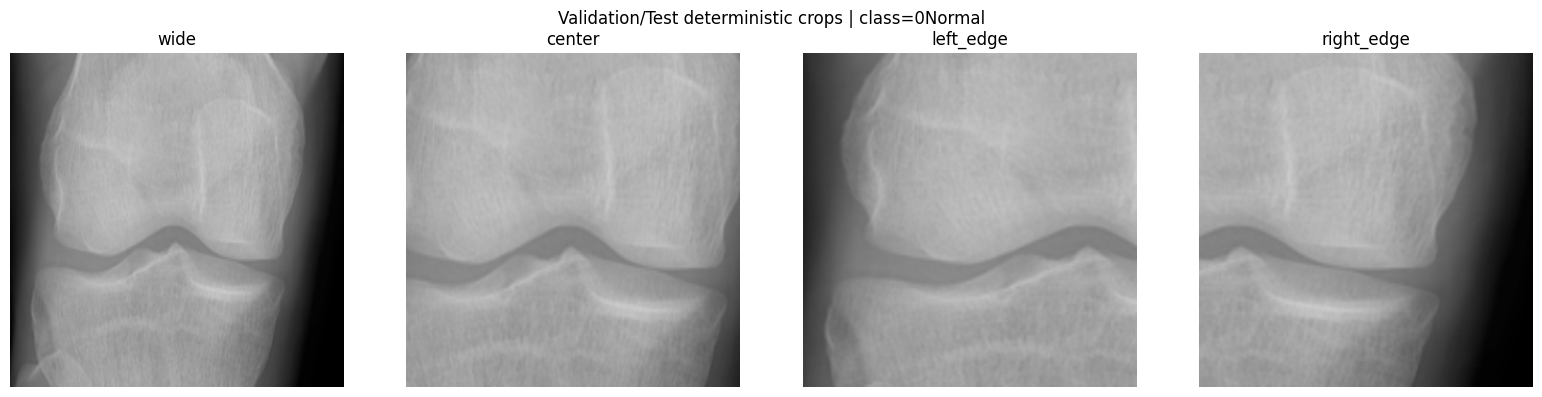

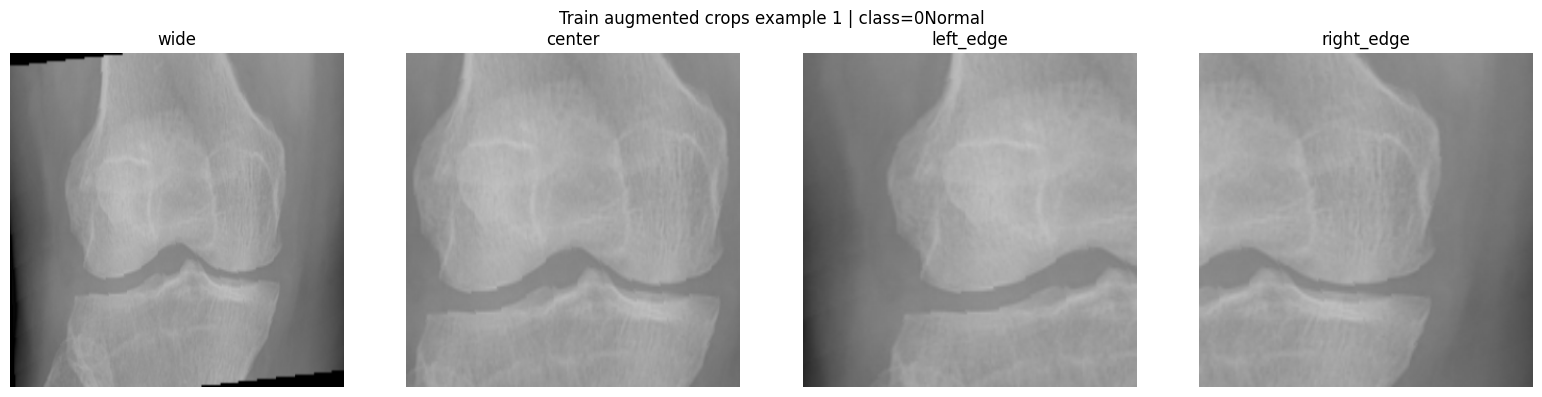

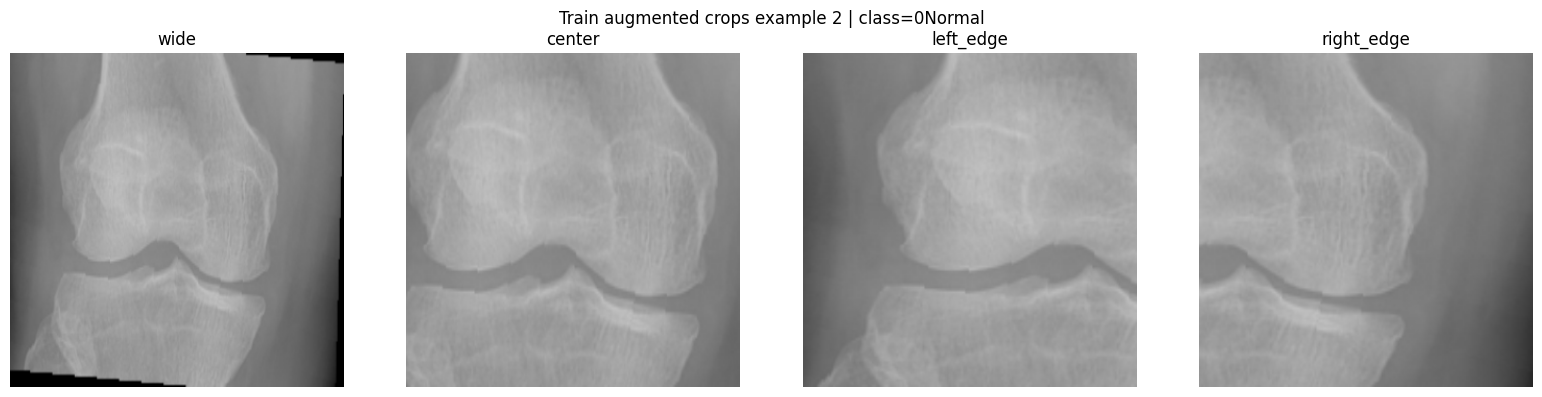

In [8]:
def denormalize_tensor(img_tensor, mean=MEAN, std=STD):
    img = img_tensor.detach().cpu().clone()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = img * std_t + mean_t
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def show_original_transform_clahe(dataset, raw_dir):
    img_path, label = dataset.samples[0]
    original = Image.open(img_path).convert("L")

    crops, _ = dataset[0]

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original\n{dataset.classes[label]}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(denormalize_tensor(crops[0]))
    plt.title("Transformed wide crop")
    plt.axis("off")

    try:
        import cv2
        arr = np.array(original)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe.apply(arr)
        plt.subplot(1, 4, 3)
        plt.imshow(clahe_img, cmap="gray")
        plt.title("CLAHE preview\nnot used in training")
        plt.axis("off")
    except Exception as e:
        plt.subplot(1, 4, 3)
        plt.imshow(original, cmap="gray")
        plt.title("CLAHE unavailable")
        plt.axis("off")
        print("CLAHE preview skipped:", e)

    plt.subplot(1, 4, 4)
    plt.imshow(denormalize_tensor(crops[1]))
    plt.title("Center crop")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_4crop_sample(dataset, idx=0, title="4-crop sample"):
    crops, label = dataset[idx]

    plt.figure(figsize=(16, 4))
    for i, crop_name in enumerate(CONFIG["CROP_NAMES"]):
        plt.subplot(1, 4, i + 1)
        plt.imshow(denormalize_tensor(crops[i]))
        plt.title(crop_name)
        plt.axis("off")

    plt.suptitle(f"{title} | class={dataset.classes[label]}", fontsize=12)
    plt.tight_layout()
    plt.show()


show_original_transform_clahe(test_dataset, TEST_DIR)
show_4crop_sample(test_dataset, idx=0, title="Validation/Test deterministic crops")
show_4crop_sample(train_dataset, idx=0, title="Train augmented crops example 1")
show_4crop_sample(train_dataset, idx=0, title="Train augmented crops example 2")

## 8. Model Definition

The model receives four crops per image. Each crop is passed through the same DenseNet121 feature extractor. The four feature vectors are averaged, then passed to a classifier.

```text
wide / center / left_edge / right_edge
        ↓ shared DenseNet121
4 feature vectors
        ↓ mean fusion
classification head
```

In [9]:
class FourCropDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3, pretrained=True):
        super().__init__()

        if pretrained:
            weights = models.DenseNet121_Weights.DEFAULT
        else:
            weights = None

        base = models.densenet121(weights=weights)

        self.features = base.features
        feature_dim = base.classifier.in_features

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def forward(self, crops):
        # crops shape: [B, N, 3, H, W]
        b, n, c, h, w = crops.shape
        x = crops.view(b * n, c, h, w)

        feats = self.features(x)
        feats = F.relu(feats)
        feats = F.adaptive_avg_pool2d(feats, (1, 1)).view(b, n, -1)

        # mean crop fusion
        fused = feats.mean(dim=1)

        logits = self.classifier(fused)
        return logits


def build_model():
    model = FourCropDenseNet121(
        num_classes=CONFIG["NUM_CLASSES"],
        dropout=CONFIG["DROPOUT"],
        pretrained=True
    )
    return model.to(device)


def set_backbone_trainable(model, trainable=True):
    for p in model.features.parameters():
        p.requires_grad = trainable


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_check = build_model()
print(model_check)
print("Trainable parameters:", count_trainable_parameters(model_check))
del model_check
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 235MB/s]


FourCropDenseNet121(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

## 9. Loss Function

The final model uses `ClassWeightedHybridChenOrdinalLoss`.

It combines:

```text
CrossEntropyLoss with class weights
+
alpha × Chen-style ordinal penalty
```

This is used because knee OA grading is ordinal:

```text
0Normal < 1Doubtful < 2Mild < 3Moderate < 4Severe
```

The next section will run a **loss penalty ablation** to select a better setting for:

- `alpha`
- `penalty_distance`
- `square_loss`
- `normalize`

The selection is based on **validation QWK**, not test-set performance.


In [10]:
class ClassWeightedHybridChenOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes=5,
        class_weights=None,
        alpha=0.20,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize

        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)

        penalty_matrix = self._create_penalty_matrix(
            num_classes=num_classes,
            penalty_distance=penalty_distance,
            normalize=normalize,
        )

        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)

        distance_matrix = torch.abs(
            class_indices.unsqueeze(0) - class_indices.unsqueeze(1)
        )

        # Chen-style modified penalty:
        # if penalty_distance=2:
        # distance 1 -> 3, distance 2 -> 5, distance 3 -> 7, distance 4 -> 9
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0

        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value

        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = self.ce_loss(logits, targets)

        probabilities = F.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]

        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = ce + self.alpha * ordinal_penalty

        if return_parts:
            return total_loss, ce, ordinal_penalty, self.alpha * ordinal_penalty

        return total_loss


criterion = ClassWeightedHybridChenOrdinalLoss(
    num_classes=CONFIG["NUM_CLASSES"],
    class_weights=class_weights,
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
).to(device)

print("Loss:", CONFIG["LOSS"])
print(f"Formula: total_loss = class_weighted_CE + {CONFIG['ORDINAL_ALPHA']} * chen_ordinal_penalty")
print("\nClass weights:")
print(class_weights.detach().cpu().numpy())
print("\nChen ordinal penalty matrix:")
print(criterion.penalty_matrix.detach().cpu().numpy())

Loss: ClassWeightedHybridChenOrdinalLoss
Formula: total_loss = class_weighted_CE + 0.2 * chen_ordinal_penalty

Class weights:
[0.6481013  0.66493505 1.5283582  1.6786885  1.4222223 ]

Chen ordinal penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]


In [11]:
# Quick one-batch loss check
model_tmp = build_model()
model_tmp.eval()

crops, labels = next(iter(train_loader))
crops = crops.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model_tmp(crops)
    total_loss, ce_loss, ordinal_loss, weighted_ordinal_loss = criterion(
        logits, labels, return_parts=True
    )

print("One batch loss check")
print("-" * 40)
print(f"Class-weighted CE loss: {ce_loss.item():.6f}")
print(f"Chen ordinal penalty:   {ordinal_loss.item():.6f}")
print(f"Weighted ordinal part:  {weighted_ordinal_loss.item():.6f}")
print(f"Total hybrid loss:      {total_loss.item():.6f}")

del model_tmp
torch.cuda.empty_cache()

One batch loss check
----------------------------------------
Class-weighted CE loss: 1.954110
Chen ordinal penalty:   0.490215
Weighted ordinal part:  0.098043
Total hybrid loss:      2.052153


## 10. Optimizer & Scheduler

Each fine-tuning strategy creates its own optimizer and scheduler.

- `full_finetuning`: all parameters are trainable from epoch 1
- `freeze_unfreeze`: DenseNet121 features are frozen first, then unfrozen

In [12]:
def make_optimizer(model, lr=None):
    if lr is None:
        lr = CONFIG["LR"]

    params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        params,
        lr=lr,
        weight_decay=CONFIG["WEIGHT_DECAY"]
    )

    return optimizer


def make_scheduler(optimizer):
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"],
        eta_min=1e-6
    )
    return scheduler

## 11. Training Loop

The training loop records:

- train loss
- validation loss
- validation accuracy
- validation macro F1
- validation QWK
- validation MAE
- validation distant errors

In [13]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    diff = np.abs(y_true - y_pred)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": float(np.mean(diff)),
        "total_errors": int(np.sum(diff > 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
    }

    return metrics


def train_one_epoch(model, loader, criterion, optimizer, scaler=None, desc="train"):
    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0

    y_true = []
    y_pred = []

    use_amp = CONFIG["USE_AMP"] and torch.cuda.is_available()

    for crops, labels in tqdm(loader, desc=desc, leave=False):
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            autocast_ctx = torch.amp.autocast("cuda", enabled=True)
        else:
            autocast_ctx = nullcontext()

        with autocast_ctx:
            logits = model(crops)
            loss, ce_loss, ord_loss, weighted_ord = criterion(
                logits,
                labels,
                return_parts=True
            )

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        running_ce += ce_loss.item() * batch_size
        running_ord += ord_loss.item() * batch_size

        preds = torch.argmax(logits.detach(), dim=1)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)

    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["chen_ordinal_penalty"] = running_ord / len(loader.dataset)

    return metrics


def evaluate(model, loader, criterion, desc="eval"):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for crops, labels in tqdm(loader, desc=desc, leave=False):
            crops = crops.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(crops)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size

            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.detach().cpu().numpy().tolist())
            y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)

    return metrics, y_true, y_pred

In [14]:
def run_one_strategy(
    strategy_cfg,
    seed=42,
    criterion_override=None,
    run_test=True,
    result_tag=None,
):
    """Train one full fine-tuning experiment under one random seed.

    Parameters
    ----------
    strategy_cfg:
        Fine-tuning strategy configuration.
    seed:
        Random seed used for model initialization and DataLoader shuffling.
    criterion_override:
        Optional loss function. If None, use the global `criterion`.
    run_test:
        If False, only validation metrics are used and the test set is not evaluated.
        This is important for hyperparameter ablation, because the test set should not
        be used when choosing the best loss penalty setting.
    result_tag:
        Optional unique name used for saving checkpoint/history files.
    """
    set_seed(seed, deterministic=CONFIG["DETERMINISTIC"])

    local_criterion = criterion_override if criterion_override is not None else criterion

    local_train_loader, local_val_loader, local_test_loader = create_loaders(
        CONFIG["BATCH_SIZE"],
        seed=seed
    )

    name = strategy_cfg["name"]
    save_tag = result_tag if result_tag is not None else f"{name}_seed{seed}"

    print("=" * 80)
    print("Running strategy:", name)
    print("Save tag:", save_tag)
    print("Seed:", seed)
    print(strategy_cfg["description"])
    print("=" * 80)

    model = build_model()

    if strategy_cfg["freeze_backbone_first"]:
        set_backbone_trainable(model, trainable=False)
        print(f"Backbone frozen for first {strategy_cfg['freeze_epochs']} epochs.")
    else:
        set_backbone_trainable(model, trainable=True)
        print("Full fine-tuning from epoch 1.")

    print("Trainable parameters at start:", count_trainable_parameters(model))

    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer)

    use_amp = CONFIG["USE_AMP"] and torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if torch.cuda.is_available() else None

    best_val_qwk = -999
    best_epoch = -1
    best_val_metrics = None
    no_improve = 0
    history = []

    best_path = MODELS_DIR / f"{save_tag}_best_state_dict.pth"

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        # Freeze/unfreeze transition, kept for compatibility.
        if strategy_cfg["freeze_backbone_first"] and epoch == strategy_cfg["freeze_epochs"] + 1:
            print("\nUnfreezing DenseNet121 backbone...")
            set_backbone_trainable(model, trainable=True)
            optimizer = make_optimizer(model)
            scheduler = make_scheduler(optimizer)
            print("Trainable parameters after unfreeze:", count_trainable_parameters(model))

        print(f"\nEpoch {epoch}/{CONFIG['EPOCHS']} | {name} | seed={seed}")

        train_metrics = train_one_epoch(
            model,
            local_train_loader,
            local_criterion,
            optimizer,
            scaler=scaler,
            desc=f"{save_tag} train"
        )

        val_metrics, _, _ = evaluate(
            model,
            local_val_loader,
            local_criterion,
            desc=f"{save_tag} val"
        )

        scheduler.step()

        row = {
            "strategy": name,
            "save_tag": save_tag,
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_ce_loss": train_metrics["ce_loss"],
            "train_chen_ordinal_penalty": train_metrics["chen_ordinal_penalty"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_qwk": val_metrics["qwk"],
            "val_mae": val_metrics["mae"],
            "val_total_errors": val_metrics["total_errors"],
            "val_adjacent_errors": val_metrics["adjacent_errors"],
            "val_distant_errors": val_metrics["distant_errors"],
        }

        history.append(row)

        print(
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_acc={row['val_accuracy']:.4f} | "
            f"val_macro_f1={row['val_macro_f1']:.4f} | "
            f"val_qwk={row['val_qwk']:.4f} | "
            f"val_mae={row['val_mae']:.4f} | "
            f"val_distant={row['val_distant_errors']}"
        )

        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            no_improve = 0

            # Save state_dict only to avoid PyTorch weights_only loading issues.
            torch.save(model.state_dict(), best_path)
            print(f"New best val QWK: {best_val_qwk:.4f}")
        else:
            no_improve += 1
            print(f"No improvement: {no_improve}/{CONFIG['PATIENCE']}")

        if no_improve >= CONFIG["PATIENCE"]:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"history_{save_tag}.csv", index=False)

    # Load best model safely.
    best_state = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(best_state)

    result = {
        "strategy": name,
        "save_tag": save_tag,
        "seed": seed,
        "description": strategy_cfg["description"],
        "best_epoch": best_epoch,
        "best_val_qwk": best_val_qwk,
        "best_val_accuracy": best_val_metrics["accuracy"] if best_val_metrics else np.nan,
        "best_val_macro_f1": best_val_metrics["macro_f1"] if best_val_metrics else np.nan,
        "best_val_weighted_f1": best_val_metrics["weighted_f1"] if best_val_metrics else np.nan,
        "best_val_mae": best_val_metrics["mae"] if best_val_metrics else np.nan,
        "best_val_total_errors": best_val_metrics["total_errors"] if best_val_metrics else np.nan,
        "best_val_adjacent_errors": best_val_metrics["adjacent_errors"] if best_val_metrics else np.nan,
        "best_val_distant_errors": best_val_metrics["distant_errors"] if best_val_metrics else np.nan,
        "model_path": str(best_path),
    }

    if run_test:
        test_metrics, test_true, test_pred = evaluate(
            model,
            local_test_loader,
            local_criterion,
            desc=f"{save_tag} test"
        )

        result.update({
            "test_accuracy": test_metrics["accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "test_weighted_f1": test_metrics["weighted_f1"],
            "test_qwk": test_metrics["qwk"],
            "test_mae": test_metrics["mae"],
            "test_total_errors": test_metrics["total_errors"],
            "test_adjacent_errors": test_metrics["adjacent_errors"],
            "test_distant_errors": test_metrics["distant_errors"],
        })

        print("\nTest results for:", name, "seed=", seed)
        for k, v in test_metrics.items():
            print(f"{k}: {v}")
    else:
        test_true, test_pred = [], []
        result.update({
            "test_accuracy": np.nan,
            "test_macro_f1": np.nan,
            "test_weighted_f1": np.nan,
            "test_qwk": np.nan,
            "test_mae": np.nan,
            "test_total_errors": np.nan,
            "test_adjacent_errors": np.nan,
            "test_distant_errors": np.nan,
        })

        print("\nValidation-only run finished. Test set was not evaluated for this ablation run.")

    del model
    torch.cuda.empty_cache()

    return result, history_df, test_true, test_pred


## 11.1 Loss Penalty Ablation

This section tests which penalty setting inside `ClassWeightedHybridChenOrdinalLoss` works best.

The ablation uses **validation QWK** to select the best setting. The test set is intentionally not used during this selection stage.

Default mode is `two_stage` to save Kaggle time:

1. Stage 1 tests `alpha × penalty_distance` using `square_loss=False` and `normalize=True`.
2. Stage 2 fixes the best `alpha` and `penalty_distance`, then tests `square_loss` and `normalize`.

For a more complete but much slower experiment, change:

```python
CONFIG["LOSS_ABLATION_MODE"] = "full_grid"
```


In [15]:
def make_hybrid_loss(
    alpha=None,
    penalty_distance=None,
    square_loss=None,
    normalize=None,
):
    """Build ClassWeightedHybridChenOrdinalLoss from explicit penalty settings."""
    return ClassWeightedHybridChenOrdinalLoss(
        num_classes=CONFIG["NUM_CLASSES"],
        class_weights=class_weights,
        alpha=CONFIG["ORDINAL_ALPHA"] if alpha is None else alpha,
        penalty_distance=CONFIG["PENALTY_DISTANCE"] if penalty_distance is None else penalty_distance,
        square_loss=CONFIG["SQUARE_LOSS"] if square_loss is None else square_loss,
        normalize=CONFIG["NORMALIZE_MATRIX"] if normalize is None else normalize,
    ).to(device)


def sanitize_float(x):
    return str(x).replace(".", "p").replace("-", "m")


def make_loss_setting_name(setting):
    return (
        f"a{sanitize_float(setting['alpha'])}_"
        f"d{setting['penalty_distance']}_"
        f"sq{int(setting['square_loss'])}_"
        f"norm{int(setting['normalize'])}"
    )


def make_full_grid_loss_settings():
    """Full factorial grid over alpha, distance, square_loss, and normalize."""
    settings = []
    seen = set()

    for alpha in CONFIG["LOSS_ABLATION_ALPHA_VALUES"]:
        for penalty_distance in CONFIG["LOSS_ABLATION_PENALTY_DISTANCE_VALUES"]:
            for square_loss in CONFIG["LOSS_ABLATION_SQUARE_LOSS_VALUES"]:
                for normalize in CONFIG["LOSS_ABLATION_NORMALIZE_VALUES"]:
                    # If alpha=0, the ordinal part is disabled, so distance/square/normalize do not matter.
                    # Keep only one CE-like baseline to avoid repeated duplicate training.
                    if alpha == 0.0:
                        setting = {
                            "alpha": 0.0,
                            "penalty_distance": 2,
                            "square_loss": False,
                            "normalize": True,
                            "stage": "ce_like_alpha0",
                        }
                    else:
                        setting = {
                            "alpha": float(alpha),
                            "penalty_distance": int(penalty_distance),
                            "square_loss": bool(square_loss),
                            "normalize": bool(normalize),
                            "stage": "full_grid",
                        }

                    key = (
                        setting["alpha"],
                        setting["penalty_distance"],
                        setting["square_loss"],
                        setting["normalize"],
                    )
                    if key not in seen:
                        settings.append(setting)
                        seen.add(key)

    return settings


def make_two_stage_loss_settings():
    """Create stage-1 settings. Stage 2 is generated after stage 1 selects best alpha/distance."""
    settings = []
    seen = set()

    # Stage 1: tune alpha and penalty_distance using the stable default penalty form.
    for alpha in CONFIG["LOSS_ABLATION_ALPHA_VALUES"]:
        for penalty_distance in CONFIG["LOSS_ABLATION_PENALTY_DISTANCE_VALUES"]:
            if alpha == 0.0:
                setting = {
                    "alpha": 0.0,
                    "penalty_distance": 2,
                    "square_loss": False,
                    "normalize": True,
                    "stage": "stage1_alpha0_ce_like",
                }
            else:
                setting = {
                    "alpha": float(alpha),
                    "penalty_distance": int(penalty_distance),
                    "square_loss": False,
                    "normalize": True,
                    "stage": "stage1_alpha_distance",
                }

            key = (
                setting["alpha"],
                setting["penalty_distance"],
                setting["square_loss"],
                setting["normalize"],
            )
            if key not in seen:
                settings.append(setting)
                seen.add(key)

    return settings


def sort_loss_ablation_results(df):
    """Rank by validation QWK first, then lower MAE, then fewer distant errors."""
    return df.sort_values(
        by=["best_val_qwk", "best_val_mae", "best_val_distant_errors", "best_val_total_errors"],
        ascending=[False, True, True, True],
    ).reset_index(drop=True)


def run_single_loss_setting(setting, stage_name):
    """Train one loss penalty setting on train set and evaluate on validation set only."""
    local_criterion = make_hybrid_loss(
        alpha=setting["alpha"],
        penalty_distance=setting["penalty_distance"],
        square_loss=setting["square_loss"],
        normalize=setting["normalize"],
    )

    loss_name = make_loss_setting_name(setting)
    strategy_cfg = {
        "name": f"loss_penalty_ablation_{loss_name}",
        "freeze_backbone_first": False,
        "freeze_epochs": 0,
        "description": (
            "Loss penalty ablation for Hybrid Chen Ordinal Loss: "
            f"alpha={setting['alpha']}, "
            f"penalty_distance={setting['penalty_distance']}, "
            f"square_loss={setting['square_loss']}, "
            f"normalize={setting['normalize']}"
        ),
    }

    result_tag = f"{stage_name}_{loss_name}_seed{CONFIG['LOSS_ABLATION_SEED']}"

    result, history_df, _, _ = run_one_strategy(
        strategy_cfg,
        seed=CONFIG["LOSS_ABLATION_SEED"],
        criterion_override=local_criterion,
        run_test=False,
        result_tag=result_tag,
    )

    result.update({
        "ablation_stage": stage_name,
        "alpha": setting["alpha"],
        "penalty_distance": setting["penalty_distance"],
        "square_loss": setting["square_loss"],
        "normalize": setting["normalize"],
    })

    # Save the matrix for this setting for checking.
    result["penalty_matrix"] = local_criterion.penalty_matrix.detach().cpu().numpy().tolist()

    return result


loss_ablation_results_df = pd.DataFrame()
best_loss_penalty_setting = {
    "alpha": CONFIG["ORDINAL_ALPHA"],
    "penalty_distance": CONFIG["PENALTY_DISTANCE"],
    "square_loss": CONFIG["SQUARE_LOSS"],
    "normalize": CONFIG["NORMALIZE_MATRIX"],
}

if CONFIG.get("RUN_LOSS_PENALTY_ABLATION", False):
    print("Running loss penalty ablation...")
    print("Mode:", CONFIG["LOSS_ABLATION_MODE"])

    # Temporarily use shorter training settings for ablation.
    original_epochs = CONFIG["EPOCHS"]
    original_patience = CONFIG["PATIENCE"]

    CONFIG["EPOCHS"] = CONFIG["LOSS_ABLATION_EPOCHS"]
    CONFIG["PATIENCE"] = CONFIG["LOSS_ABLATION_PATIENCE"]

    try:
        ablation_results = []

        if CONFIG["LOSS_ABLATION_MODE"] == "full_grid":
            settings = make_full_grid_loss_settings()
            print(f"Full-grid settings to test: {len(settings)}")

            for idx, setting in enumerate(settings, start=1):
                print("\n" + "#" * 90)
                print(f"Loss penalty ablation {idx}/{len(settings)}")
                print(setting)
                print("#" * 90)
                ablation_results.append(run_single_loss_setting(setting, stage_name="full_grid"))

        elif CONFIG["LOSS_ABLATION_MODE"] == "two_stage":
            stage1_settings = make_two_stage_loss_settings()
            print(f"Stage 1 settings to test: {len(stage1_settings)}")

            for idx, setting in enumerate(stage1_settings, start=1):
                print("\n" + "#" * 90)
                print(f"Stage 1 loss penalty ablation {idx}/{len(stage1_settings)}")
                print(setting)
                print("#" * 90)
                ablation_results.append(run_single_loss_setting(setting, stage_name="stage1"))

            stage1_df = sort_loss_ablation_results(pd.DataFrame(ablation_results))
            stage1_df.to_csv(RESULTS_DIR / "loss_penalty_ablation_stage1_results.csv", index=False)

            print("\nBest Stage 1 setting:")
            display(stage1_df.head(1))

            best_stage1 = stage1_df.iloc[0].to_dict()

            # Stage 2: fix best alpha and distance, then test square_loss and normalize.
            stage2_settings = []
            seen = set()
            for square_loss in CONFIG["LOSS_ABLATION_SQUARE_LOSS_VALUES"]:
                for normalize in CONFIG["LOSS_ABLATION_NORMALIZE_VALUES"]:
                    setting = {
                        "alpha": float(best_stage1["alpha"]),
                        "penalty_distance": int(best_stage1["penalty_distance"]),
                        "square_loss": bool(square_loss),
                        "normalize": bool(normalize),
                        "stage": "stage2_square_normalize",
                    }
                    key = (
                        setting["alpha"],
                        setting["penalty_distance"],
                        setting["square_loss"],
                        setting["normalize"],
                    )
                    if key not in seen:
                        stage2_settings.append(setting)
                        seen.add(key)

            print(f"\nStage 2 settings to test: {len(stage2_settings)}")

            for idx, setting in enumerate(stage2_settings, start=1):
                print("\n" + "#" * 90)
                print(f"Stage 2 loss penalty ablation {idx}/{len(stage2_settings)}")
                print(setting)
                print("#" * 90)
                ablation_results.append(run_single_loss_setting(setting, stage_name="stage2"))

        else:
            raise ValueError("CONFIG['LOSS_ABLATION_MODE'] must be 'two_stage' or 'full_grid'.")

        loss_ablation_results_df = sort_loss_ablation_results(pd.DataFrame(ablation_results))
        loss_ablation_results_df.to_csv(RESULTS_DIR / "loss_penalty_ablation_all_results.csv", index=False)

        print("\nFinal loss penalty ablation ranking:")
        display(loss_ablation_results_df[[
            "ablation_stage",
            "alpha",
            "penalty_distance",
            "square_loss",
            "normalize",
            "best_epoch",
            "best_val_qwk",
            "best_val_accuracy",
            "best_val_macro_f1",
            "best_val_mae",
            "best_val_total_errors",
            "best_val_adjacent_errors",
            "best_val_distant_errors",
            "model_path",
        ]])

        best_row = loss_ablation_results_df.iloc[0].to_dict()
        best_loss_penalty_setting = {
            "alpha": float(best_row["alpha"]),
            "penalty_distance": int(best_row["penalty_distance"]),
            "square_loss": bool(best_row["square_loss"]),
            "normalize": bool(best_row["normalize"]),
        }

        print("\nSelected best loss penalty setting based on validation QWK:")
        print(json.dumps(best_loss_penalty_setting, indent=2))

    finally:
        # Restore final model training settings.
        CONFIG["EPOCHS"] = original_epochs
        CONFIG["PATIENCE"] = original_patience

    # Update CONFIG so the final model uses the selected best penalty setting.
    CONFIG["ORDINAL_ALPHA"] = best_loss_penalty_setting["alpha"]
    CONFIG["PENALTY_DISTANCE"] = best_loss_penalty_setting["penalty_distance"]
    CONFIG["SQUARE_LOSS"] = best_loss_penalty_setting["square_loss"]
    CONFIG["NORMALIZE_MATRIX"] = best_loss_penalty_setting["normalize"]

    # Rebuild the global criterion for final model training.
    criterion = make_hybrid_loss(
        alpha=CONFIG["ORDINAL_ALPHA"],
        penalty_distance=CONFIG["PENALTY_DISTANCE"],
        square_loss=CONFIG["SQUARE_LOSS"],
        normalize=CONFIG["NORMALIZE_MATRIX"],
    )

    print("\nFinal loss setting used for full model training:")
    print(f"alpha={CONFIG['ORDINAL_ALPHA']}")
    print(f"penalty_distance={CONFIG['PENALTY_DISTANCE']}")
    print(f"square_loss={CONFIG['SQUARE_LOSS']}")
    print(f"normalize={CONFIG['NORMALIZE_MATRIX']}")
    print("\nSelected penalty matrix:")
    print(criterion.penalty_matrix.detach().cpu().numpy())

else:
    print("Loss penalty ablation skipped because CONFIG['RUN_LOSS_PENALTY_ABLATION'] is False.")
    print("Using default loss setting:")
    print(json.dumps(best_loss_penalty_setting, indent=2))


Running loss penalty ablation...
Mode: two_stage
Stage 1 settings to test: 13

##########################################################################################
Stage 1 loss penalty ablation 1/13
{'alpha': 0.0, 'penalty_distance': 2, 'square_loss': False, 'normalize': True, 'stage': 'stage1_alpha0_ce_like'}
##########################################################################################
Running strategy: loss_penalty_ablation_a0p0_d2_sq0_norm1
Save tag: stage1_a0p0_d2_sq0_norm1_seed42
Seed: 42
Loss penalty ablation for Hybrid Chen Ordinal Loss: alpha=0.0, penalty_distance=2, square_loss=False, normalize=True
Full fine-tuning from epoch 1.
Trainable parameters at start: 6958981

Epoch 1/12 | loss_penalty_ablation_a0p0_d2_sq0_norm1 | seed=42


train_loss=1.3478 | val_loss=0.9925 | val_acc=0.6644 | val_macro_f1=0.6414 | val_qwk=0.8308 | val_mae=0.4452 | val_distant=12
New best val QWK: 0.8308

Epoch 2/12 | loss_penalty_ablation_a0p0_d2_sq0_norm1 | seed=42


train_loss=0.9176 | val_loss=0.8136 | val_acc=0.6781 | val_macro_f1=0.6756 | val_qwk=0.8282 | val_mae=0.4315 | val_distant=13
No improvement: 1/4

Epoch 3/12 | loss_penalty_ablation_a0p0_d2_sq0_norm1 | seed=42


train_loss=0.7399 | val_loss=0.6286 | val_acc=0.7671 | val_macro_f1=0.7585 | val_qwk=0.8761 | val_mae=0.3082 | val_distant=9
New best val QWK: 0.8761

Epoch 4/12 | loss_penalty_ablation_a0p0_d2_sq0_norm1 | seed=42


train_loss=0.6078 | val_loss=0.5712 | val_acc=0.7740 | val_macro_f1=0.7765 | val_qwk=0.9011 | val_mae=0.2671 | val_distant=4
New best val QWK: 0.9011

Epoch 5/12 | loss_penalty_ablation_a0p0_d2_sq0_norm1 | seed=42


...

train_loss=0.3136 | val_loss=0.4460 | val_acc=0.8425 | val_macro_f1=0.8443 | val_qwk=0.9358 | val_mae=0.1849 | val_distant=3
New best val QWK: 0.9358

Epoch 11/12 | loss_penalty_ablation_a0p05_d1_sq1_norm0 | seed=42


train_loss=0.3246 | val_loss=0.4402 | val_acc=0.8425 | val_macro_f1=0.8457 | val_qwk=0.9350 | val_mae=0.1849 | val_distant=3
No improvement: 1/4

Epoch 12/12 | loss_penalty_ablation_a0p05_d1_sq1_norm0 | seed=42


train_loss=0.2979 | val_loss=0.4363 | val_acc=0.8493 | val_macro_f1=0.8493 | val_qwk=0.9374 | val_mae=0.1781 | val_distant=3
New best val QWK: 0.9374

Validation-only run finished. Test set was not evaluated for this ablation run.

Final loss penalty ablation ranking:


,ablation_stage,alpha,penalty_distance,square_loss,normalize,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_mae,best_val_total_errors,best_val_adjacent_errors,best_val_distant_errors,model_path
0,stage1,0.05,1,False,True,10,0.957644,0.876712,0.874213,0.136986,18,16,2,/kaggle/working/final_full_finetuning_4crop_mu...
1,stage2,0.05,1,False,True,10,0.957644,0.876712,0.874213,0.136986,18,16,2,/kaggle/working/final_full_finetuning_4crop_mu...
2,stage1,0.05,2,False,True,10,0.955576,0.869863,0.868368,0.143836,19,17,2,/kaggle/working/final_full_finetuning_4crop_mu...
3,stage1,0.30,3,False,True,12,0.954276,0.863014,0.868863,0.150685,20,18,2,/kaggle/working/final_full_finetuning_4crop_mu...
4,stage1,0.10,3,False,True,11,0.953795,0.863014,0.853960,0.150685,20,18,2,/kaggle/working/final_full_finetuning_4crop_mu...
5,stage1,0.00,2,False,True,10,0.940642,0.863014,0.860452,0.164384,20,17,3,/kaggle/working/final_full_finetuning_4crop_mu...
6,stage1,0.10,1,False,True,10,0.940642,0.863014,0.860452,0.164384,20,17,3,/kaggle/working/final_full_finetuning_4crop_mu...
7,stage1,0.20,1,False,True,10,0.938892,0.856164,0.851881,0.171233,21,18,3,/kaggle/working/final_full_finetuning_4crop_mu...
8,stage2,0.05,1,True,True,10,0.938892,0.856164,0.851881,0.171233,21,18,3,/kaggle/working/final_full_finetuning_4crop_mu...
9,stage2,0.05,1,False,False,11,0.938263,0.856164,0.856743,0.171233,21,18,3,/kaggle/working/final_full_finetuning_4crop_mu...



Selected best loss penalty setting based on validation QWK:
{
  "alpha": 0.05,
  "penalty_distance": 1,
  "square_loss": false,
  "normalize": true
}

Final loss setting used for full model training:
alpha=0.05
penalty_distance=1
square_loss=False
normalize=True

Selected penalty matrix:
[[0.  0.4 0.6 0.8 1. ]
 [0.4 0.  0.4 0.6 0.8]
 [0.6 0.4 0.  0.4 0.6]
 [0.8 0.6 0.4 0.  0.4]
 [1.  0.8 0.6 0.4 0. ]]


## 12. Final Training Section

After the loss penalty ablation, the final model is trained using:

```text
Full Fine-tuning + 4-crop DenseNet121 + selected Hybrid Chen Ordinal Loss setting
```

The best checkpoint is selected by validation QWK.


In [16]:
# ============================================================
# Final full fine-tuning run under the main seed
# ============================================================

all_results = []
all_histories = {}
all_test_predictions = {}

for strategy_cfg in FINETUNING_EXPERIMENTS:
    result, history_df, test_true, test_pred = run_one_strategy(
        strategy_cfg,
        seed=CONFIG["SEED"]
    )

    all_results.append(result)
    all_histories[strategy_cfg["name"]] = history_df
    all_test_predictions[strategy_cfg["name"]] = {
        "true": test_true,
        "pred": test_pred,
        "seed": CONFIG["SEED"],
        "model_path": result["model_path"],
    }

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_DIR / "final_full_finetuning_result.csv", index=False)

display(results_df.sort_values("best_val_qwk", ascending=False))


Running strategy: full_finetuning
Save tag: full_finetuning_seed42
Seed: 42
Final model: train DenseNet121 backbone and classifier from epoch 1.
Full fine-tuning from epoch 1.
Trainable parameters at start: 6958981

Epoch 1/30 | full_finetuning | seed=42


train_loss=1.3663 | val_loss=1.0049 | val_acc=0.6849 | val_macro_f1=0.6595 | val_qwk=0.8494 | val_mae=0.4110 | val_distant=12
New best val QWK: 0.8494

Epoch 2/30 | full_finetuning | seed=42


train_loss=0.9229 | val_loss=0.7627 | val_acc=0.7192 | val_macro_f1=0.7113 | val_qwk=0.8674 | val_mae=0.3562 | val_distant=9
New best val QWK: 0.8674

Epoch 3/30 | full_finetuning | seed=42


train_loss=0.7454 | val_loss=0.6224 | val_acc=0.7877 | val_macro_f1=0.7926 | val_qwk=0.9012 | val_mae=0.2603 | val_distant=5
New best val QWK: 0.9012

Epoch 4/30 | full_finetuning | seed=42


train_loss=0.6187 | val_loss=0.6053 | val_acc=0.7671 | val_macro_f1=0.7706 | val_qwk=0.8847 | val_mae=0.2945 | val_distant=7
No improvement: 1/7

Epoch 5/30 | full_finetuning | seed=42


...

train_loss=0.0942 | val_loss=0.3318 | val_acc=0.8973 | val_macro_f1=0.9008 | val_qwk=0.9459 | val_mae=0.1301 | val_distant=2
No improvement: 5/7

Epoch 21/30 | full_finetuning | seed=42


train_loss=0.1010 | val_loss=0.3020 | val_acc=0.8836 | val_macro_f1=0.8905 | val_qwk=0.9356 | val_mae=0.1507 | val_distant=3
No improvement: 6/7

Epoch 22/30 | full_finetuning | seed=42


train_loss=0.1031 | val_loss=0.3147 | val_acc=0.8767 | val_macro_f1=0.8854 | val_qwk=0.9349 | val_mae=0.1575 | val_distant=3
No improvement: 7/7
Early stopping triggered.



Test results for: full_finetuning seed= 42
accuracy: 0.8503401360544217
macro_f1: 0.8428255340419588
weighted_f1: 0.8509552311297307
qwk: 0.921233590331319
mae: 0.19727891156462585
total_errors: 44
adjacent_errors: 32
distant_errors: 12
loss: 0.44361662558045517


,strategy,save_tag,seed,description,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_weighted_f1,best_val_mae,...,best_val_distant_errors,model_path,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors
0,full_finetuning,full_finetuning_seed42,42,Final model: train DenseNet121 backbone and cl...,15,0.963056,0.89726,0.897111,0.896822,0.116438,...,2,/kaggle/working/final_full_finetuning_4crop_mu...,0.85034,0.842826,0.850955,0.921234,0.197279,44,32,12


## 13. Test Evaluation

The final Full Fine-tuning strategy uses the best penalty setting selected from the validation set.

The test set is evaluated only after this selection.


In [17]:
# Since this notebook directly uses Full Fine-tuning as the final model,
# the selected strategy is fixed as full_finetuning.

best_result = results_df[results_df["strategy"] == "full_finetuning"].iloc[0].to_dict()
selected_strategy = "full_finetuning"

print("Final strategy:", selected_strategy)
print(json.dumps(best_result, indent=2))

selected_true = all_test_predictions[selected_strategy]["true"]
selected_pred = all_test_predictions[selected_strategy]["pred"]

print("\nFinal full fine-tuning test metrics:")
for k in [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]:
    print(f"{k}: {best_result[k]}")


Final strategy: full_finetuning
{
  "strategy": "full_finetuning",
  "save_tag": "full_finetuning_seed42",
  "seed": 42,
  "description": "Final model: train DenseNet121 backbone and classifier from epoch 1.",
  "best_epoch": 15,
  "best_val_qwk": 0.9630557898541993,
  "best_val_accuracy": 0.8972602739726028,
  "best_val_macro_f1": 0.8971108537517349,
  "best_val_weighted_f1": 0.8968224737720178,
  "best_val_mae": 0.11643835616438356,
  "best_val_total_errors": 15,
  "best_val_adjacent_errors": 13,
  "best_val_distant_errors": 2,
  "model_path": "/kaggle/working/final_full_finetuning_4crop_multiseed_confidence/models/full_finetuning_seed42_best_state_dict.pth",
  "test_accuracy": 0.8503401360544217,
  "test_macro_f1": 0.8428255340419588,
  "test_weighted_f1": 0.8509552311297307,
  "test_qwk": 0.921233590331319,
  "test_mae": 0.19727891156462585,
  "test_total_errors": 44,
  "test_adjacent_errors": 32,
  "test_distant_errors": 12
}

Final full fine-tuning test metrics:
test_accuracy: 0.

## 13.1 Multi-seed Robustness Experiment

This section repeats the selected final strategy under multiple random seeds. The goal is to check whether the final result is stable instead of depending on one lucky seed.

The output table reports each seed separately and then summarizes the final metrics as **mean ± standard deviation**.


In [18]:
# ============================================================
# Multi-seed robustness experiment for final full fine-tuning
# ============================================================

seed_results_df = pd.DataFrame()
multi_seed_summary_df = pd.DataFrame()
seed_test_predictions = {}

if CONFIG.get("RUN_MULTI_SEED", True):
    FINAL_STRATEGY_NAME = "full_finetuning"

    final_strategy_cfg = None
    for cfg in FINETUNING_EXPERIMENTS:
        if cfg["name"] == FINAL_STRATEGY_NAME:
            final_strategy_cfg = cfg
            break

    if final_strategy_cfg is None:
        raise ValueError(f"Cannot find strategy config for: {FINAL_STRATEGY_NAME}")

    print("Final strategy for multi-seed experiment:", FINAL_STRATEGY_NAME)
    print("Seeds:", CONFIG["SEEDS"])

    seed_results = []

    for seed in CONFIG["SEEDS"]:
        print("\n" + "#" * 90)
        print(f"Running final full fine-tuning model with seed = {seed}")
        print("#" * 90)

        # Reuse the already trained final model for the main seed to avoid one duplicate run.
        if seed == CONFIG["SEED"]:
            print(f"Reusing final full fine-tuning result from the main run for seed={seed}.")
            result = dict(best_result)
            result["seed"] = seed
            test_true = selected_true
            test_pred = selected_pred
        else:
            result, history_df, test_true, test_pred = run_one_strategy(
                final_strategy_cfg,
                seed=seed
            )

        seed_results.append(result)
        seed_test_predictions[seed] = {
            "true": test_true,
            "pred": test_pred,
            "model_path": result["model_path"],
        }

    seed_results_df = pd.DataFrame(seed_results)
    seed_results_df.to_csv(RESULTS_DIR / "multi_seed_test_results.csv", index=False)

    display(seed_results_df)
else:
    print("Multi-seed experiment skipped because CONFIG['RUN_MULTI_SEED'] is False.")


Final strategy for multi-seed experiment: full_finetuning
Seeds: [42, 123, 2024, 3407, 777]

##########################################################################################
Running final full fine-tuning model with seed = 42
##########################################################################################
Reusing final full fine-tuning result from the main run for seed=42.

##########################################################################################
Running final full fine-tuning model with seed = 123
##########################################################################################
Running strategy: full_finetuning
Save tag: full_finetuning_seed123
Seed: 123
Final model: train DenseNet121 backbone and classifier from epoch 1.
Full fine-tuning from epoch 1.
Trainable parameters at start: 6958981

Epoch 1/30 | full_finetuning | seed=123


train_loss=1.4344 | val_loss=1.0921 | val_acc=0.5685 | val_macro_f1=0.5050 | val_qwk=0.7219 | val_mae=0.6644 | val_distant=25
New best val QWK: 0.7219

Epoch 2/30 | full_finetuning | seed=123


train_loss=0.9745 | val_loss=0.7987 | val_acc=0.7192 | val_macro_f1=0.6988 | val_qwk=0.8721 | val_mae=0.3562 | val_distant=9
New best val QWK: 0.8721

Epoch 3/30 | full_finetuning | seed=123


train_loss=0.7693 | val_loss=0.6768 | val_acc=0.7466 | val_macro_f1=0.7326 | val_qwk=0.8836 | val_mae=0.3151 | val_distant=7
New best val QWK: 0.8836

Epoch 4/30 | full_finetuning | seed=123


train_loss=0.6409 | val_loss=0.5431 | val_acc=0.7945 | val_macro_f1=0.7881 | val_qwk=0.9153 | val_mae=0.2466 | val_distant=5
New best val QWK: 0.9153

Epoch 5/30 | full_finetuning | seed=123


...

train_loss=0.0939 | val_loss=0.2573 | val_acc=0.9110 | val_macro_f1=0.9109 | val_qwk=0.9627 | val_mae=0.1027 | val_distant=1
No improvement: 5/7

Epoch 25/30 | full_finetuning | seed=777


train_loss=0.0983 | val_loss=0.2494 | val_acc=0.8904 | val_macro_f1=0.8921 | val_qwk=0.9427 | val_mae=0.1370 | val_distant=2
No improvement: 6/7

Epoch 26/30 | full_finetuning | seed=777


train_loss=0.0850 | val_loss=0.2476 | val_acc=0.8973 | val_macro_f1=0.8990 | val_qwk=0.9445 | val_mae=0.1301 | val_distant=2
No improvement: 7/7
Early stopping triggered.



Test results for: full_finetuning seed= 777
accuracy: 0.8503401360544217
macro_f1: 0.8495022619591726
weighted_f1: 0.8512814505283695
qwk: 0.9238300666983992
mae: 0.19047619047619047
total_errors: 44
adjacent_errors: 35
distant_errors: 9
loss: 0.4259784305024715


,strategy,save_tag,seed,description,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_weighted_f1,best_val_mae,...,best_val_distant_errors,model_path,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors
0,full_finetuning,full_finetuning_seed42,42,Final model: train DenseNet121 backbone and cl...,15,0.963056,0.897260,0.897111,0.896822,0.116438,...,2,/kaggle/working/final_full_finetuning_4crop_mu...,0.850340,0.842826,0.850955,0.921234,0.197279,44,32,12
1,full_finetuning,full_finetuning_seed123,123,Final model: train DenseNet121 backbone and cl...,13,0.969996,0.904110,0.912540,0.904268,0.102740,...,1,/kaggle/working/final_full_finetuning_4crop_mu...,0.836735,0.839054,0.837421,0.894476,0.227891,48,35,13
2,full_finetuning,full_finetuning_seed2024,2024,Final model: train DenseNet121 backbone and cl...,14,0.959702,0.917808,0.918815,0.917748,0.102740,...,2,/kaggle/working/final_full_finetuning_4crop_mu...,0.863946,0.863538,0.863616,0.918445,0.187075,40,30,10
3,full_finetuning,full_finetuning_seed3407,3407,Final model: train DenseNet121 backbone and cl...,25,0.964976,0.917808,0.924869,0.917726,0.095890,...,1,/kaggle/working/final_full_finetuning_4crop_mu...,0.850340,0.850202,0.850381,0.891318,0.224490,44,29,15
4,full_finetuning,full_finetuning_seed777,777,Final model: train DenseNet121 backbone and cl...,19,0.976748,0.910959,0.909879,0.912614,0.089041,...,0,/kaggle/working/final_full_finetuning_4crop_mu...,0.850340,0.849502,0.851281,0.923830,0.190476,44,35,9


## 13.2 Multi-seed Summary: Mean ± Standard Deviation

For the report or presentation, use the `mean±std` column. This is stronger than reporting only one test result because it shows robustness across different random initializations and data-loader shuffling.


In [19]:
# ============================================================
# Multi-seed summary: mean ± std
# ============================================================

metric_cols = [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]

summary_rows = []

if len(seed_results_df) > 0:
    for metric in metric_cols:
        values = seed_results_df[metric].astype(float)

        summary_rows.append({
            "metric": metric,
            "mean": float(values.mean()),
            "std": float(values.std(ddof=0)),
            "min": float(values.min()),
            "max": float(values.max()),
            "mean±std": f"{values.mean():.4f} ± {values.std(ddof=0):.4f}",
        })

    multi_seed_summary_df = pd.DataFrame(summary_rows)
    multi_seed_summary_df.to_csv(RESULTS_DIR / "multi_seed_summary.csv", index=False)

    display(multi_seed_summary_df)
else:
    print("No multi-seed results available.")

,metric,mean,std,min,max,mean±std
0,test_accuracy,0.850340,0.008605,0.836735,0.863946,0.8503 ± 0.0086
1,test_macro_f1,0.849024,0.008368,0.839054,0.863538,0.8490 ± 0.0084
2,test_weighted_f1,0.850731,0.008290,0.837421,0.863616,0.8507 ± 0.0083
3,test_qwk,0.909861,0.013991,0.891318,0.923830,0.9099 ± 0.0140
4,test_mae,0.205442,0.017290,0.187075,0.227891,0.2054 ± 0.0173
5,test_total_errors,44.000000,2.529822,40.000000,48.000000,44.0000 ± 2.5298
6,test_adjacent_errors,32.200000,2.481935,29.000000,35.000000,32.2000 ± 2.4819
7,test_distant_errors,11.800000,2.135416,9.000000,15.000000,11.8000 ± 2.1354


## 13.3 Final Model Confidence and Calibration Analysis

This section estimates how confident the selected final model is for each test prediction.

Main confidence definitions:

- **confidence** = maximum softmax probability of the predicted class.
- **margin_top1_top2** = probability difference between the most likely and second most likely class.
- **entropy** = uncertainty of the full probability distribution. Lower entropy means the model is more confident.
- **ECE** = Expected Calibration Error. Lower ECE means confidence is better aligned with actual accuracy.

Important wording for the report: this is **model prediction confidence**, not true medical certainty.


In [20]:
# ============================================================
# Final model confidence and calibration analysis
# ============================================================

def expected_calibration_error(confidences, correct, n_bins=10):
    confidences = np.array(confidences)
    correct = np.array(correct).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_accuracy = np.mean(correct[in_bin])
            bin_confidence = np.mean(confidences[in_bin])
            ece += prop_in_bin * abs(bin_accuracy - bin_confidence)

    return float(ece)


def evaluate_with_confidence(model, loader, criterion=None, desc="confidence_eval"):
    model.eval()

    running_loss = 0.0
    records = []

    with torch.no_grad():
        for batch_idx, (crops, labels) in enumerate(tqdm(loader, desc=desc, leave=False)):
            crops = crops.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(crops)

            if criterion is not None:
                loss = criterion(logits, labels)
                running_loss += loss.item() * labels.size(0)

            probs = F.softmax(logits, dim=1)

            confidences, preds = torch.max(probs, dim=1)
            top2 = torch.topk(probs, k=2, dim=1).values
            margins = top2[:, 0] - top2[:, 1]

            # Normalized entropy: lower = more confident, higher = more uncertain.
            entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=1)
            entropy = entropy / math.log(CONFIG["NUM_CLASSES"])

            probs_cpu = probs.detach().cpu().numpy()
            labels_cpu = labels.detach().cpu().numpy()
            preds_cpu = preds.detach().cpu().numpy()
            conf_cpu = confidences.detach().cpu().numpy()
            margin_cpu = margins.detach().cpu().numpy()
            entropy_cpu = entropy.detach().cpu().numpy()

            for i in range(labels.size(0)):
                true_label = int(labels_cpu[i])
                pred_label = int(preds_cpu[i])
                correct = true_label == pred_label

                row = {
                    "sample_index": batch_idx * loader.batch_size + i,
                    "true": true_label,
                    "pred": pred_label,
                    "true_class": class_names[true_label],
                    "pred_class": class_names[pred_label],
                    "correct": bool(correct),
                    "confidence": float(conf_cpu[i]),
                    "margin_top1_top2": float(margin_cpu[i]),
                    "entropy": float(entropy_cpu[i]),
                }

                for class_idx, class_name in enumerate(class_names):
                    row[f"prob_{class_idx}_{class_name}"] = float(probs_cpu[i, class_idx])

                records.append(row)

    conf_df = pd.DataFrame(records)

    y_true = conf_df["true"].values
    y_pred = conf_df["pred"].values

    metrics = compute_metrics(y_true, y_pred)

    if criterion is not None:
        metrics["loss"] = running_loss / len(loader.dataset)

    correct_mask = conf_df["correct"].values.astype(bool)

    def safe_mean(values):
        values = np.array(values)
        if len(values) == 0:
            return np.nan
        return float(np.mean(values))

    confidence_summary = {
        "mean_confidence": float(conf_df["confidence"].mean()),
        "median_confidence": float(conf_df["confidence"].median()),
        "mean_confidence_correct": safe_mean(conf_df.loc[correct_mask, "confidence"]),
        "mean_confidence_wrong": safe_mean(conf_df.loc[~correct_mask, "confidence"]),
        "mean_margin_top1_top2": float(conf_df["margin_top1_top2"].mean()),
        "mean_entropy": float(conf_df["entropy"].mean()),
        "high_confidence_wrong_count_0.80": int(((conf_df["confidence"] >= 0.80) & (~conf_df["correct"])).sum()),
        "high_confidence_wrong_count_0.90": int(((conf_df["confidence"] >= 0.90) & (~conf_df["correct"])).sum()),
        "ece_10_bins": expected_calibration_error(
            conf_df["confidence"].values,
            conf_df["correct"].values,
            n_bins=CONFIG.get("CONFIDENCE_BINS", 10)
        ),
    }

    return metrics, conf_df, confidence_summary


confidence_metrics = {}
confidence_summary = {}
confidence_df = pd.DataFrame()
confidence_by_class_df = pd.DataFrame()
high_confidence_wrong_df = pd.DataFrame()

if CONFIG.get("RUN_CONFIDENCE_ANALYSIS", True):
    # Load selected best model from the initial strategy comparison.
    confidence_model = build_model()
    best_state = torch.load(best_result["model_path"], map_location=device, weights_only=True)
    confidence_model.load_state_dict(best_state)
    confidence_model.eval()

    # Deterministic test loader.
    _, _, confidence_test_loader = create_loaders(
        CONFIG["BATCH_SIZE"],
        seed=CONFIG["SEED"]
    )

    confidence_metrics, confidence_df, confidence_summary = evaluate_with_confidence(
        confidence_model,
        confidence_test_loader,
        criterion=criterion,
        desc="selected model confidence"
    )

    confidence_df.to_csv(RESULTS_DIR / "selected_model_confidence_predictions.csv", index=False)

    confidence_summary_df = pd.DataFrame([confidence_summary])
    confidence_summary_df.to_csv(RESULTS_DIR / "selected_model_confidence_summary.csv", index=False)

    confidence_by_class_df = (
        confidence_df
        .groupby("true_class")
        .agg(
            samples=("sample_index", "count"),
            accuracy=("correct", "mean"),
            mean_confidence=("confidence", "mean"),
            mean_margin=("margin_top1_top2", "mean"),
            mean_entropy=("entropy", "mean"),
        )
        .reset_index()
    )
    confidence_by_class_df.to_csv(RESULTS_DIR / "selected_model_confidence_by_true_class.csv", index=False)

    high_confidence_wrong_df = confidence_df[
        (confidence_df["confidence"] >= 0.80) & (~confidence_df["correct"])
    ].sort_values("confidence", ascending=False)
    high_confidence_wrong_df.to_csv(RESULTS_DIR / "selected_model_high_confidence_wrong.csv", index=False)

    print("Confidence metrics:")
    print(json.dumps(confidence_metrics, indent=2))

    print("\nConfidence summary:")
    print(json.dumps(confidence_summary, indent=2))

    print("\nConfidence by true class:")
    display(confidence_by_class_df)

    print("\nFirst few prediction-level confidence records:")
    display(confidence_df.head())

    print("\nHigh-confidence wrong predictions, confidence >= 0.80:")
    display(high_confidence_wrong_df.head(20))

    del confidence_model
    torch.cuda.empty_cache()
else:
    print("Confidence analysis skipped because CONFIG['RUN_CONFIDENCE_ANALYSIS'] is False.")

Confidence metrics:
{
  "accuracy": 0.8503401360544217,
  "macro_f1": 0.8428255340419588,
  "weighted_f1": 0.8509552311297307,
  "qwk": 0.921233590331319,
  "mae": 0.19727891156462585,
  "total_errors": 44,
  "adjacent_errors": 32,
  "distant_errors": 12,
  "loss": 0.44361662558045517
}

Confidence summary:
{
  "mean_confidence": 0.8821741997384701,
  "median_confidence": 0.969245433807373,
  "mean_confidence_correct": 0.9115582994222641,
  "mean_confidence_wrong": 0.7152190878987312,
  "mean_margin_top1_top2": 0.7979694231837785,
  "mean_entropy": 0.21349151424753168,
  "high_confidence_wrong_count_0.80": 15,
  "high_confidence_wrong_count_0.90": 10,
  "ece_10_bins": 0.03904817562524962
}

Confidence by true class:


,true_class,samples,accuracy,mean_confidence,mean_margin,mean_entropy
0,0Normal,91,0.923077,0.910040,0.845618,0.163166
1,1Doubtful,88,0.784091,0.856838,0.749983,0.266951
2,2Mild,38,0.842105,0.840795,0.742533,0.287756
3,3Moderate,35,0.885714,0.947087,0.913404,0.105902
4,4Severe,42,0.809524,0.858228,0.749234,0.232986



First few prediction-level confidence records:


,sample_index,true,pred,true_class,pred_class,correct,confidence,margin_top1_top2,entropy,prob_0_0Normal,prob_1_1Doubtful,prob_2_2Mild,prob_3_3Moderate,prob_4_4Severe
0,0,0,0,0Normal,0Normal,True,0.986302,0.976768,0.052929,0.986302,0.009534,0.001831,0.000874,0.001460
1,1,0,0,0Normal,0Normal,True,0.997023,0.995578,0.014761,0.997023,0.001445,0.000916,0.000435,0.000181
2,2,0,0,0Normal,0Normal,True,0.897945,0.801349,0.221610,0.897945,0.096596,0.002249,0.002047,0.001163
3,3,0,0,0Normal,0Normal,True,0.521779,0.083644,0.539833,0.521779,0.438135,0.022866,0.006711,0.010509
4,4,0,0,0Normal,0Normal,True,0.920127,0.876986,0.229243,0.920127,0.043140,0.021580,0.007885,0.007268



High-confidence wrong predictions, confidence >= 0.80:


,sample_index,true,pred,true_class,pred_class,correct,confidence,margin_top1_top2,entropy,prob_0_0Normal,prob_1_1Doubtful,prob_2_2Mild,prob_3_3Moderate,prob_4_4Severe
142,142,1,0,1Doubtful,0Normal,False,0.990227,0.983764,0.040250,0.990227,0.006463,0.001354,0.000813,0.001143
114,114,1,0,1Doubtful,0Normal,False,0.988159,0.979997,0.046944,0.988159,0.008161,0.000897,0.001675,0.001108
238,238,3,4,3Moderate,4Severe,False,0.987206,0.975376,0.045160,0.000111,0.000181,0.000672,0.011830,0.987206
178,178,1,0,1Doubtful,0Normal,False,0.982977,0.968519,0.059792,0.982977,0.014458,0.000980,0.000715,0.000870
192,192,2,3,2Mild,3Moderate,False,0.978521,0.958204,0.068044,0.000340,0.000318,0.020317,0.978521,0.000505
111,111,1,0,1Doubtful,0Normal,False,0.976579,0.961915,0.083551,0.976579,0.014664,0.002555,0.005263,0.000938
152,152,1,0,1Doubtful,0Normal,False,0.948259,0.906609,0.149240,0.948259,0.041649,0.002957,0.003596,0.003539
141,141,1,0,1Doubtful,0Normal,False,0.939723,0.892833,0.170444,0.939723,0.046890,0.004638,0.003997,0.004753
189,189,2,3,2Mild,3Moderate,False,0.937170,0.878987,0.159204,0.001139,0.001455,0.058182,0.937170,0.002054
259,259,4,1,4Severe,1Doubtful,False,0.905487,0.852319,0.253120,0.009311,0.905487,0.053168,0.002080,0.029955


## 13.4 Reliability Diagram

The reliability diagram compares model confidence with actual accuracy. A perfectly calibrated model would lie close to the diagonal line.


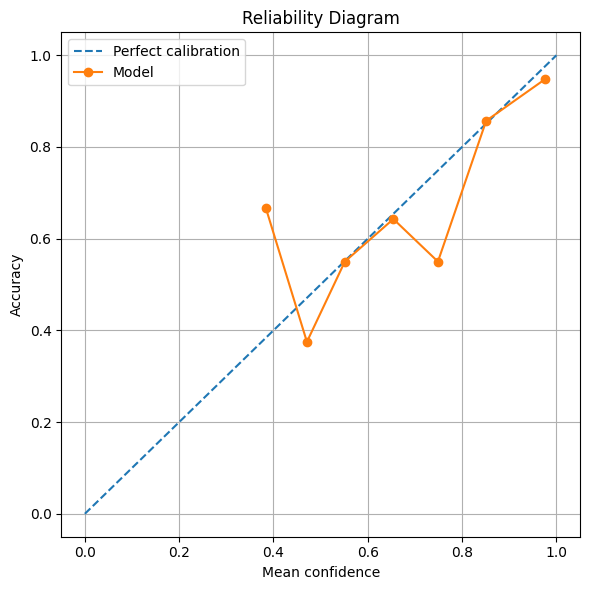

,mean_confidence,accuracy,count
0,0.383861,0.666667,3
1,0.470898,0.375000,8
2,0.551315,0.550000,20
3,0.654193,0.642857,14
4,0.748738,0.550000,20
5,0.851084,0.857143,35
6,0.976767,0.948454,194


Saved reliability diagram to: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/figures/selected_model_reliability_diagram.png


In [21]:
# ============================================================
# Reliability diagram for calibration analysis
# ============================================================

def plot_reliability_diagram(conf_df, n_bins=10, save_path=None):
    if len(conf_df) == 0:
        print("No confidence dataframe available. Reliability diagram skipped.")
        return

    confidences = conf_df["confidence"].values
    correct = conf_df["correct"].values.astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_confidences = []
    bin_accuracies = []
    bin_counts = []

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        if np.sum(in_bin) > 0:
            bin_confidences.append(float(np.mean(confidences[in_bin])))
            bin_accuracies.append(float(np.mean(correct[in_bin])))
            bin_counts.append(int(np.sum(in_bin)))

    reliability_df = pd.DataFrame({
        "mean_confidence": bin_confidences,
        "accuracy": bin_accuracies,
        "count": bin_counts,
    })

    reliability_df.to_csv(RESULTS_DIR / "selected_model_reliability_bins.csv", index=False)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(bin_confidences, bin_accuracies, marker="o", label="Model")
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    display(reliability_df)


reliability_path = FIGURES_DIR / "selected_model_reliability_diagram.png"

plot_reliability_diagram(
    confidence_df,
    n_bins=CONFIG.get("CONFIDENCE_BINS", 10),
    save_path=reliability_path
)

print("Saved reliability diagram to:", reliability_path)

## 13.1 Per-class Recall and F1

In [22]:
report_dict = classification_report(
    selected_true,
    selected_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

classwise_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
classwise_df.to_csv(RESULTS_DIR / "selected_classwise_recall_f1.csv")

display(classwise_df)

,precision,recall,f1-score,support
0Normal,0.857143,0.923077,0.888889,91.00000
1Doubtful,0.907895,0.784091,0.841463,88.00000
2Mild,0.695652,0.842105,0.761905,38.00000
3Moderate,0.837838,0.885714,0.861111,35.00000
4Severe,0.918919,0.809524,0.860759,42.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.843489,0.848902,0.842826,294.00000
weighted avg,0.857988,0.850340,0.850955,294.00000


,precision,recall,f1-score,support
0Normal,0.857143,0.923077,0.888889,91.0
1Doubtful,0.907895,0.784091,0.841463,88.0
2Mild,0.695652,0.842105,0.761905,38.0
3Moderate,0.837838,0.885714,0.861111,35.0
4Severe,0.918919,0.809524,0.860759,42.0


## 14. Confusion Matrix

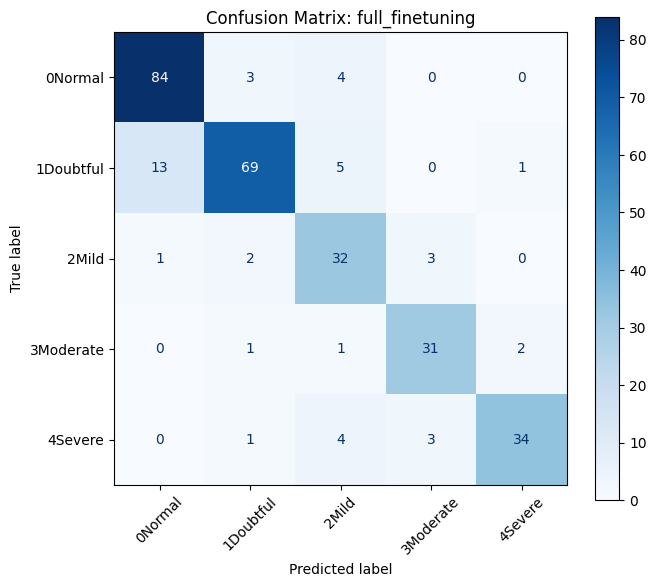

Saved confusion matrix to: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/figures/confusion_matrix_selected.png


In [23]:
cm = confusion_matrix(selected_true, selected_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix: {selected_strategy}")
plt.tight_layout()

cm_path = FIGURES_DIR / "confusion_matrix_selected.png"
fig.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path)

## 15. Error Analysis

Because knee OA grading is ordinal, adjacent and distant errors are reported separately.

- adjacent error: prediction differs by 1 grade
- distant error: prediction differs by 2 or more grades

In [24]:
error_df = pd.DataFrame({
    "true": selected_true,
    "pred": selected_pred,
})
error_df["true_class"] = error_df["true"].apply(lambda x: class_names[int(x)])
error_df["pred_class"] = error_df["pred"].apply(lambda x: class_names[int(x)])
error_df["distance"] = (error_df["true"] - error_df["pred"]).abs()
error_df["correct"] = error_df["distance"] == 0
error_df["error_type"] = np.where(
    error_df["distance"] == 0,
    "correct",
    np.where(error_df["distance"] == 1, "adjacent", "distant")
)

display(error_df["error_type"].value_counts())
display(error_df.groupby(["true_class", "pred_class", "error_type"]).size().reset_index(name="count"))

error_df.to_csv(RESULTS_DIR / "selected_error_analysis.csv", index=False)

print("Total samples:", len(error_df))
print("Correct:", int((error_df["distance"] == 0).sum()))
print("Adjacent errors:", int((error_df["distance"] == 1).sum()))
print("Distant errors:", int((error_df["distance"] >= 2).sum()))

error_type
correct     250
adjacent     32
distant      12
Name: count, dtype: int64

,true_class,pred_class,error_type,count
0,0Normal,0Normal,correct,84
1,0Normal,1Doubtful,adjacent,3
2,0Normal,2Mild,distant,4
3,1Doubtful,0Normal,adjacent,13
4,1Doubtful,1Doubtful,correct,69
5,1Doubtful,2Mild,adjacent,5
6,1Doubtful,4Severe,distant,1
7,2Mild,0Normal,distant,1
8,2Mild,1Doubtful,adjacent,2
9,2Mild,2Mild,correct,32


Total samples: 294
Correct: 250
Adjacent errors: 32
Distant errors: 12


wrong samples: 44 / 294
Showing original images directly from file paths. Transforms are not applied.


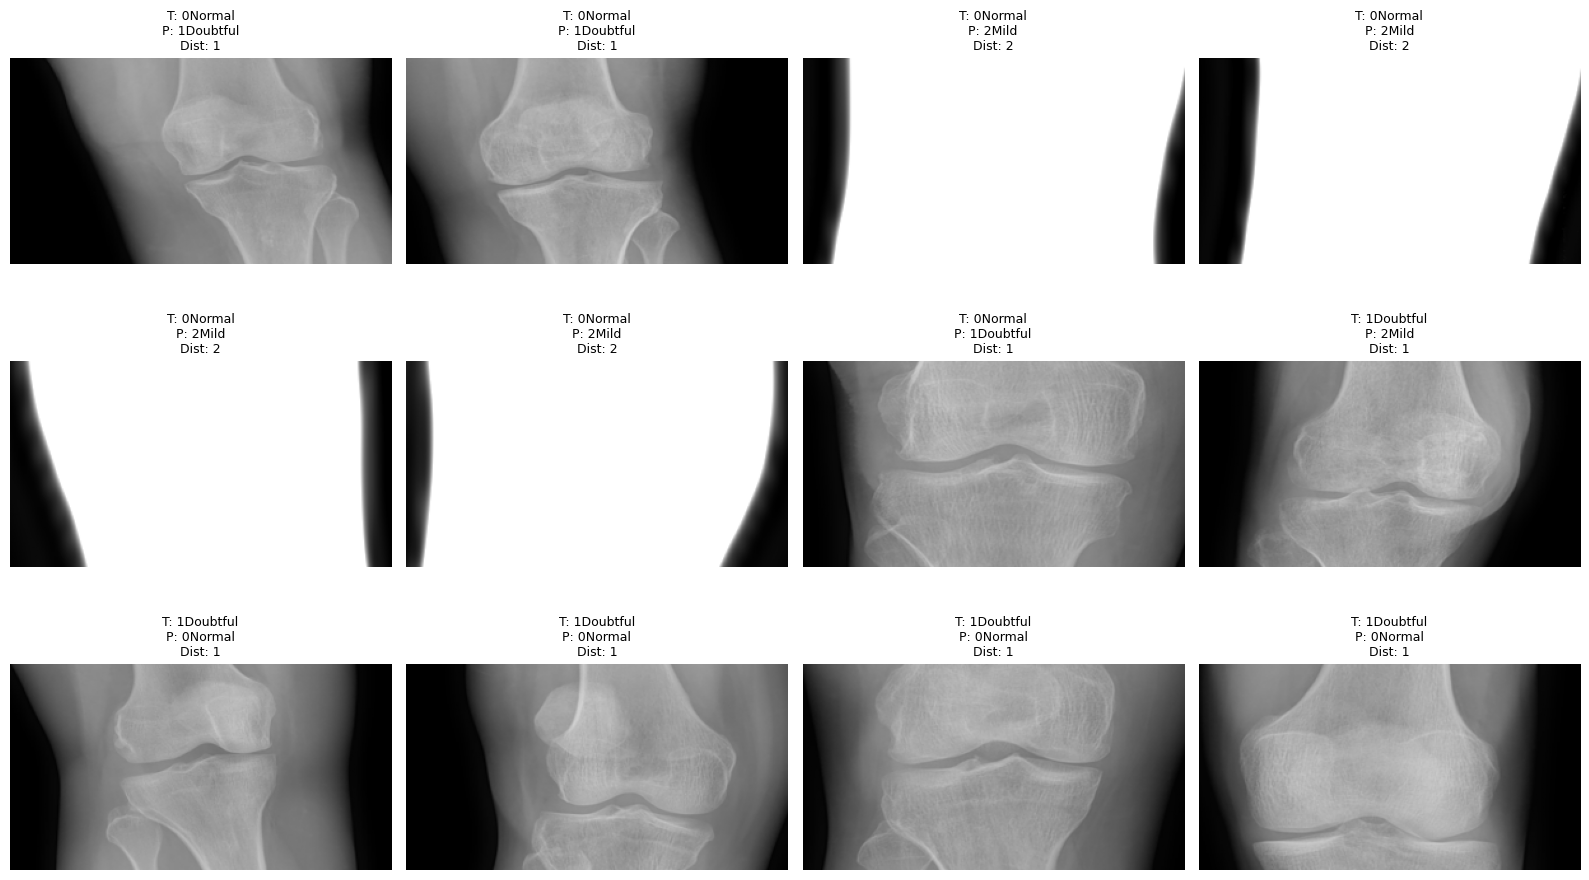

In [25]:
def show_misclassified_raw_images(test_dataset, y_true, y_pred, class_names, max_images=12):
    wrong_indices = [
        i for i, (t, p) in enumerate(zip(y_true, y_pred))
        if int(t) != int(p)
    ]

    print(f"wrong samples: {len(wrong_indices)} / {len(y_true)}")
    print("Showing original images directly from file paths. Transforms are not applied.")

    show_indices = wrong_indices[:max_images]

    if len(show_indices) == 0:
        print("No misclassified samples.")
        return

    cols = 4
    rows = math.ceil(len(show_indices) / cols)

    plt.figure(figsize=(cols * 4, rows * 3.2))

    for plot_i, idx in enumerate(show_indices, start=1):
        img_path, true_label_from_dataset = test_dataset.samples[idx]

        true_label = int(y_true[idx])
        pred_label = int(y_pred[idx])
        dist = abs(true_label - pred_label)

        img = Image.open(img_path).convert("L")

        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
        plt.title(
            f"T: {class_names[true_label]}\n"
            f"P: {class_names[pred_label]}\n"
            f"Dist: {dist}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


raw_test_dataset = datasets.ImageFolder(TEST_DIR, transform=None)

show_misclassified_raw_images(
    test_dataset=raw_test_dataset,
    y_true=selected_true,
    y_pred=selected_pred,
    class_names=class_names,
    max_images=12
)

## 16. Grad-CAM

Grad-CAM is used to visualize whether the model focuses on clinically meaningful regions.

This section shows:

1. a correctly classified example
2. an incorrectly classified example

For 4-crop input, Grad-CAM is shown for all four crops.

Correct samples: 250
Wrong samples: 44


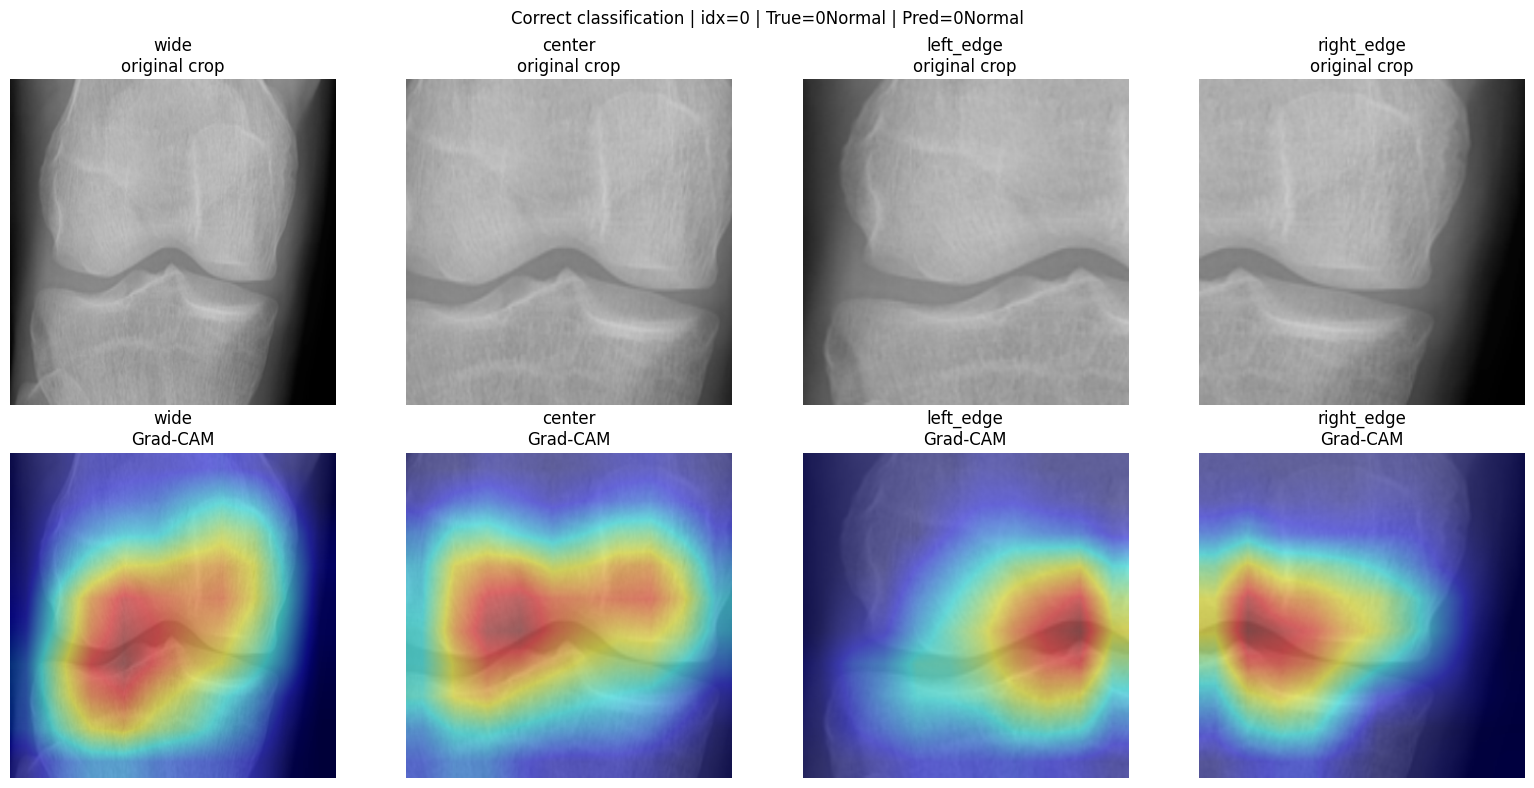

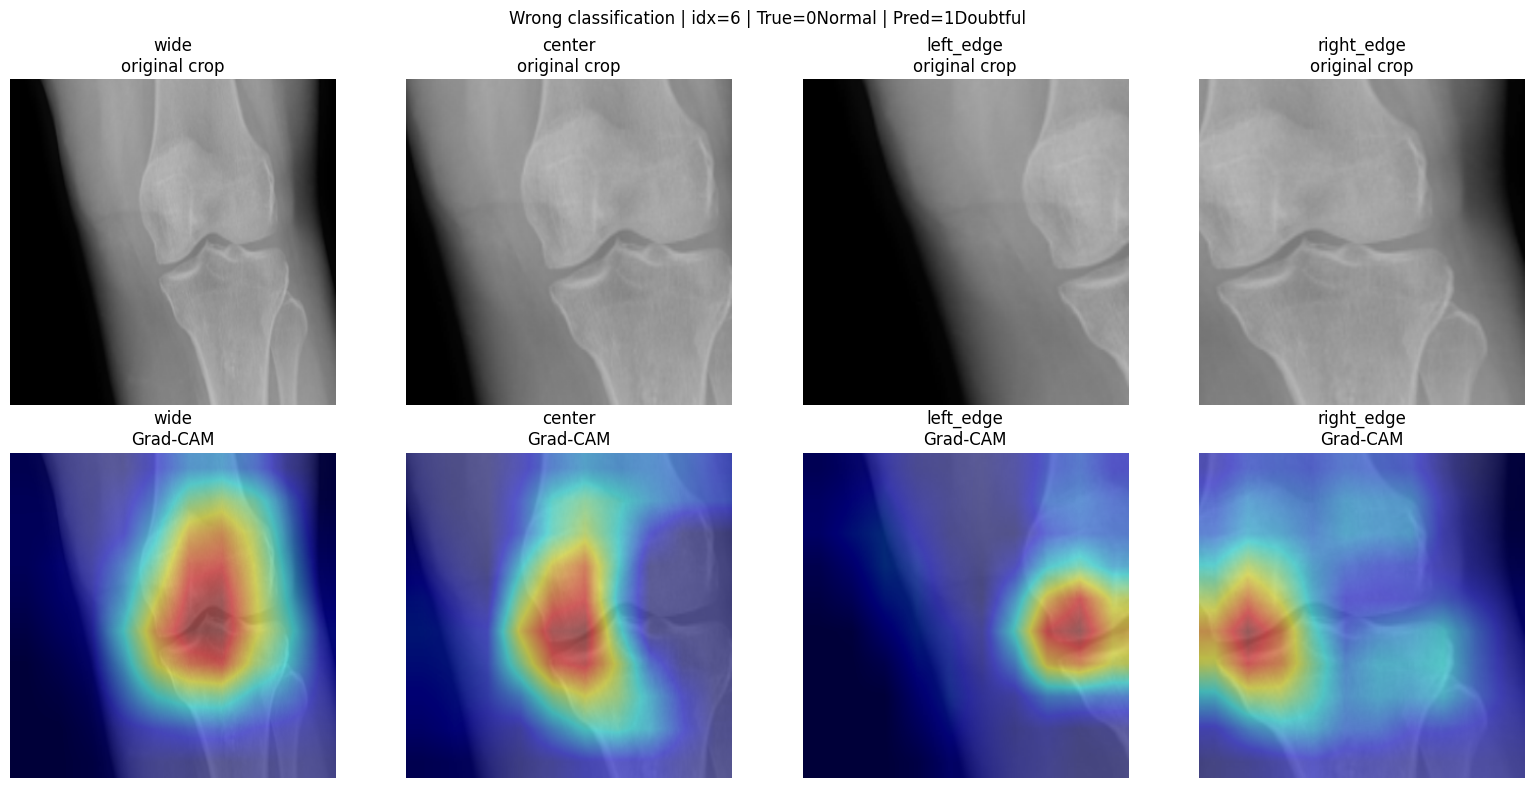

In [26]:
class GradCAM4Crop:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = self.target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, crops, target_class=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        crops = crops.unsqueeze(0).to(device)  # [1, 4, 3, H, W]

        logits = self.model(crops)

        if target_class is None:
            target_class = int(torch.argmax(logits, dim=1).item())

        score = logits[0, target_class]
        score.backward()

        # activations/grads shape: [B*N, C, h, w], here [4, C, h, w]
        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cams = (weights * activations).sum(dim=1)
        cams = F.relu(cams)

        cam_list = []
        for i in range(cams.size(0)):
            cam = cams[i]
            cam = cam - cam.min()
            if cam.max() > 0:
                cam = cam / cam.max()
            cam_list.append(cam.detach().cpu().numpy())

        return cam_list, logits.detach().cpu()


def overlay_cam_on_image(img_np, cam):
    try:
        import cv2
        cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.55 * img_np + 0.45 * heatmap
        overlay = np.clip(overlay, 0, 1)
        return overlay
    except Exception:
        # Fallback: just return image; CAM can be shown separately if cv2 is unavailable.
        return img_np


def show_gradcam_for_index(model, dataset, idx, y_true, y_pred, title_prefix="Grad-CAM"):
    crops, label = dataset[idx]

    cam = GradCAM4Crop(model, model.features.norm5)
    cam_list, logits = cam.generate(crops, target_class=int(y_pred[idx]))
    cam.remove()

    pred_label = int(y_pred[idx])
    true_label = int(y_true[idx])

    plt.figure(figsize=(16, 8))

    for i, crop_name in enumerate(CONFIG["CROP_NAMES"]):
        img_np = denormalize_tensor(crops[i])
        overlay = overlay_cam_on_image(img_np, cam_list[i])

        plt.subplot(2, 4, i + 1)
        plt.imshow(img_np)
        plt.title(f"{crop_name}\noriginal crop")
        plt.axis("off")

        plt.subplot(2, 4, i + 5)
        plt.imshow(overlay)
        plt.title(f"{crop_name}\nGrad-CAM")
        plt.axis("off")

    plt.suptitle(
        f"{title_prefix} | idx={idx} | True={class_names[true_label]} | Pred={class_names[pred_label]}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# Load selected best model
best_model = build_model()
best_state = torch.load(best_result["model_path"], map_location=device, weights_only=True)
best_model.load_state_dict(best_state)
best_model.eval()

correct_indices = [
    i for i, (t, p) in enumerate(zip(selected_true, selected_pred))
    if int(t) == int(p)
]
wrong_indices = [
    i for i, (t, p) in enumerate(zip(selected_true, selected_pred))
    if int(t) != int(p)
]

print("Correct samples:", len(correct_indices))
print("Wrong samples:", len(wrong_indices))

if len(correct_indices) > 0:
    show_gradcam_for_index(
        best_model,
        test_dataset,
        correct_indices[0],
        selected_true,
        selected_pred,
        title_prefix="Correct classification"
    )

if len(wrong_indices) > 0:
    show_gradcam_for_index(
        best_model,
        test_dataset,
        wrong_indices[0],
        selected_true,
        selected_pred,
        title_prefix="Wrong classification"
    )

## 17. Final Summary

# Experiment Conclusion

This experiment uses Full Fine-tuning as the final training strategy and adds a loss penalty ablation before final training.

The final model is selected using validation QWK and then evaluated with test metrics, confusion matrix, class-wise F1/recall, adjacent/distant error analysis, multi-seed robustness, confidence analysis, and Grad-CAM visualizations.


In [27]:
print("=" * 80)
print("Final Full Fine-tuning Model Summary")
print("=" * 80)

print("Final strategy:", selected_strategy)
print("Model:", CONFIG["MODEL_NAME"])
print("Loss:", CONFIG["LOSS"])
print("Image size:", CONFIG["IMG_SIZE"])
print("Learning rate:", CONFIG["LR"])
print("Ordinal alpha:", CONFIG["ORDINAL_ALPHA"])
print("Penalty distance:", CONFIG["PENALTY_DISTANCE"])
print("Square loss:", CONFIG["SQUARE_LOSS"])
print("Normalize matrix:", CONFIG["NORMALIZE_MATRIX"])
print("Dropout:", CONFIG["DROPOUT"])
print("Main seed:", CONFIG["SEED"])

print("\nFinal full fine-tuning test metrics:")
for k in [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]:
    print(f"{k}: {best_result[k]}")

print("\nFinal run result:")
display(results_df)

if "loss_ablation_results_df" in globals() and len(loss_ablation_results_df) > 0:
    print("\nLoss penalty ablation ranking:")
    display(loss_ablation_results_df[[
        "ablation_stage", "alpha", "penalty_distance", "square_loss", "normalize",
        "best_val_qwk", "best_val_mae", "best_val_distant_errors"
    ]])

if "multi_seed_summary_df" in globals() and len(multi_seed_summary_df) > 0:
    print("\nMulti-seed robustness summary:")
    display(multi_seed_summary_df)

if "confidence_summary" in globals() and len(confidence_summary) > 0:
    print("\nConfidence summary:")
    for k, v in confidence_summary.items():
        print(f"{k}: {v}")


Final Full Fine-tuning Model Summary
Final strategy: full_finetuning
Model: 4-crop DenseNet121 Full Fine-tuning
Loss: ClassWeightedHybridChenOrdinalLoss
Image size: 320
Learning rate: 5e-05
Ordinal alpha: 0.05
Penalty distance: 1
Square loss: False
Normalize matrix: True
Dropout: 0.3
Main seed: 42

Final full fine-tuning test metrics:
test_accuracy: 0.8503401360544217
test_macro_f1: 0.8428255340419588
test_weighted_f1: 0.8509552311297307
test_qwk: 0.921233590331319
test_mae: 0.19727891156462585
test_total_errors: 44
test_adjacent_errors: 32
test_distant_errors: 12

Final run result:


,strategy,save_tag,seed,description,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_weighted_f1,best_val_mae,...,best_val_distant_errors,model_path,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors
0,full_finetuning,full_finetuning_seed42,42,Final model: train DenseNet121 backbone and cl...,15,0.963056,0.89726,0.897111,0.896822,0.116438,...,2,/kaggle/working/final_full_finetuning_4crop_mu...,0.85034,0.842826,0.850955,0.921234,0.197279,44,32,12



Loss penalty ablation ranking:


,ablation_stage,alpha,penalty_distance,square_loss,normalize,best_val_qwk,best_val_mae,best_val_distant_errors
0,stage1,0.05,1,False,True,0.957644,0.136986,2
1,stage2,0.05,1,False,True,0.957644,0.136986,2
2,stage1,0.05,2,False,True,0.955576,0.143836,2
3,stage1,0.30,3,False,True,0.954276,0.150685,2
4,stage1,0.10,3,False,True,0.953795,0.150685,2
5,stage1,0.00,2,False,True,0.940642,0.164384,3
6,stage1,0.10,1,False,True,0.940642,0.164384,3
7,stage1,0.20,1,False,True,0.938892,0.171233,3
8,stage2,0.05,1,True,True,0.938892,0.171233,3
9,stage2,0.05,1,False,False,0.938263,0.171233,3



Multi-seed robustness summary:


,metric,mean,std,min,max,mean±std
0,test_accuracy,0.850340,0.008605,0.836735,0.863946,0.8503 ± 0.0086
1,test_macro_f1,0.849024,0.008368,0.839054,0.863538,0.8490 ± 0.0084
2,test_weighted_f1,0.850731,0.008290,0.837421,0.863616,0.8507 ± 0.0083
3,test_qwk,0.909861,0.013991,0.891318,0.923830,0.9099 ± 0.0140
4,test_mae,0.205442,0.017290,0.187075,0.227891,0.2054 ± 0.0173
5,test_total_errors,44.000000,2.529822,40.000000,48.000000,44.0000 ± 2.5298
6,test_adjacent_errors,32.200000,2.481935,29.000000,35.000000,32.2000 ± 2.4819
7,test_distant_errors,11.800000,2.135416,9.000000,15.000000,11.8000 ± 2.1354



Confidence summary:
mean_confidence: 0.8821741997384701
median_confidence: 0.969245433807373
mean_confidence_correct: 0.9115582994222641
mean_confidence_wrong: 0.7152190878987312
mean_margin_top1_top2: 0.7979694231837785
mean_entropy: 0.21349151424753168
high_confidence_wrong_count_0.80: 15
high_confidence_wrong_count_0.90: 10
ece_10_bins: 0.03904817562524962


## 18. Save Results

The following files are saved:

- `metrics.json`
- `summary.json`
- `loss_penalty_ablation_all_results.csv`
- `loss_penalty_ablation_stage1_results.csv` when using two-stage mode
- `final_full_finetuning_result.csv`
- `multi_seed_test_results.csv`
- `multi_seed_summary.csv`
- `selected_model_confidence_predictions.csv`
- `selected_model_confidence_summary.csv`
- `selected_classwise_recall_f1.csv`
- `selected_error_analysis.csv`
- `confusion_matrix_selected.png`


In [28]:
def make_json_serializable(obj):
    """Convert NumPy/Pandas objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if pd.isna(obj) if not isinstance(obj, (dict, list, tuple, np.ndarray)) else False:
        return None
    return obj


metrics = {
    "config": CONFIG,
    "crop_config": CROP_CONFIG,
    "selected_strategy": selected_strategy,
    "selected_result": best_result,
    "all_results": results_df.to_dict(orient="records"),
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist(),
}

if "loss_ablation_results_df" in globals() and len(loss_ablation_results_df) > 0:
    metrics["loss_penalty_ablation_results"] = loss_ablation_results_df.to_dict(orient="records")
    metrics["best_loss_penalty_setting"] = best_loss_penalty_setting

if "seed_results_df" in globals() and len(seed_results_df) > 0:
    metrics["multi_seed_results"] = seed_results_df.to_dict(orient="records")

if "multi_seed_summary_df" in globals() and len(multi_seed_summary_df) > 0:
    metrics["multi_seed_summary"] = multi_seed_summary_df.to_dict(orient="records")

if "confidence_summary" in globals() and len(confidence_summary) > 0:
    metrics["confidence_summary"] = confidence_summary
    metrics["confidence_metrics"] = confidence_metrics

if "confidence_by_class_df" in globals() and len(confidence_by_class_df) > 0:
    metrics["confidence_by_class"] = confidence_by_class_df.to_dict(orient="records")

metrics_path = RESULTS_DIR / "metrics.json"
summary_path = RESULTS_DIR / "summary.json"

with open(metrics_path, "w") as f:
    json.dump(make_json_serializable(metrics), f, indent=2)

summary = {
    "experiment_name": CONFIG["EXPERIMENT_NAME"],
    "selected_strategy": selected_strategy,
    "model": CONFIG["MODEL_NAME"],
    "loss": CONFIG["LOSS"],
    "best_loss_penalty_setting": best_loss_penalty_setting if "best_loss_penalty_setting" in globals() else None,
    "ordinal_alpha": CONFIG["ORDINAL_ALPHA"],
    "penalty_distance": CONFIG["PENALTY_DISTANCE"],
    "square_loss": CONFIG["SQUARE_LOSS"],
    "normalize_matrix": CONFIG["NORMALIZE_MATRIX"],
    "test_accuracy": best_result["test_accuracy"],
    "test_macro_f1": best_result["test_macro_f1"],
    "test_weighted_f1": best_result["test_weighted_f1"],
    "test_qwk": best_result["test_qwk"],
    "test_mae": best_result["test_mae"],
    "test_total_errors": best_result["test_total_errors"],
    "test_adjacent_errors": best_result["test_adjacent_errors"],
    "test_distant_errors": best_result["test_distant_errors"],
}

if "multi_seed_summary_df" in globals() and len(multi_seed_summary_df) > 0:
    summary["multi_seed_summary"] = multi_seed_summary_df.to_dict(orient="records")

if "confidence_summary" in globals() and len(confidence_summary) > 0:
    summary["mean_confidence"] = confidence_summary.get("mean_confidence")
    summary["mean_confidence_correct"] = confidence_summary.get("mean_confidence_correct")
    summary["mean_confidence_wrong"] = confidence_summary.get("mean_confidence_wrong")
    summary["mean_margin_top1_top2"] = confidence_summary.get("mean_margin_top1_top2")
    summary["mean_entropy"] = confidence_summary.get("mean_entropy")
    summary["ece_10_bins"] = confidence_summary.get("ece_10_bins")
    summary["high_confidence_wrong_count_0.80"] = confidence_summary.get("high_confidence_wrong_count_0.80")
    summary["high_confidence_wrong_count_0.90"] = confidence_summary.get("high_confidence_wrong_count_0.90")

with open(summary_path, "w") as f:
    json.dump(make_json_serializable(summary), f, indent=2)

print("Saved metrics to:", metrics_path)
print("Saved summary to:", summary_path)
print("Saved confusion matrix to:", cm_path)
print("Saved results directory:", RESULTS_DIR)
print("Saved figures directory:", FIGURES_DIR)

Saved metrics to: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/results/metrics.json
Saved summary to: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/results/summary.json
Saved confusion matrix to: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/figures/confusion_matrix_selected.png
Saved results directory: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/results
Saved figures directory: /kaggle/working/final_full_finetuning_4crop_multiseed_confidence/figures
